# Extracting evidence-linked abundance drivers from species-account text

[Plant Atlas 2020](https://plantatlas2020.org/) | [Motivating paper](https://doi.org/10.1111/2041-210X.14492) | Ongoing Development

Primary Contact: Lily Gouldsbrough, lilgou@ceh.ac.uk | Notebook Top-to-Bottom Runtime < 10 Minutes

**Challenge:**  
Species accounts contain useful ecological knowledge about habitat, management, biogeography and likely reasons for change. However, that knowledge is usually written as prose, which makes it difficult to reuse directly in structured workflows such as causal diagrams or expert-review tables.

**Approach:**  
This notebook demonstrates a constrained workflow for using a small local instruction-tuned language model to extract candidate ecological driver relationships from species-account text. Each sentence is processed with a short context window, and the model returns a small JSON object containing a driver phrase, driver type, target, effect direction, confidence score and evidence quote. Standard Python code then validates, groups and aggregates these rows into evidence-linked candidate edges for expert review.

**Important:**  
The output is not an automatically generated causal model. The model proposes evidence-linked rows; the analyst decides whether the evidence is useful, whether the direction is plausible and whether the edge belongs in a causal diagram.


## Introduction

Biodiversity records are rarely collected from a perfectly representative sample of places. Some sites are visited more often because they are accessible, well known, close to recorders, or more likely to contain species of interest. These patterns matter when inferring changes in species' distributions or abundance from opportunistic records.

Causal diagrams are one way to reason about this problem. They make explicit which processes are thought to affect a species, which processes affect where records are collected, and where those processes overlap. Boyd et al. (2025) discuss this in the context of using causal diagrams and superpopulation models to correct geographic biases in biodiversity monitoring data.

In practice, much of the ecological knowledge needed to draft these diagrams is held as prose. Plant Atlas-style species accounts describe habitat, management, broad biogeography, recent trends and likely reasons for change, but those descriptions are not directly usable as candidate graph edges.

This notebook asks a narrow practical question: can a small local LLM help convert species-account prose into an evidence-linked table of candidate abundance drivers for expert review?

The included demo data are synthetic Plant Atlas-style examples. They mimic the structure of local account extracts, but they are not copied Plant Atlas prose and should not be quoted as Plant Atlas content.

### Running the notebook

Clone the accompanying notebook repository, create the conda environment, and point `MODEL_PATH` to a locally available Hugging Face-compatible instruction model.

```bash
conda env create -f environment.yml
conda activate plant-atlas-llm-dag
```

A typical local-model setup is:

```bash
export MODEL_PATH=../models/qwen2.5-3b-instruct
export LLM_LOAD_IN_4BIT=1
export LLM_4BIT_QUANT_TYPE=nf4
export LLM_4BIT_USE_DOUBLE_QUANT=1
export LLM_4BIT_COMPUTE_DTYPE=float16
export TRANSFORMERS_OFFLINE=1
export HF_HUB_OFFLINE=1

# Recommended first run.
export LLM_MAX_SENTENCES=10
export LLM_BATCH_SIZE=1
export LLM_MAX_NEW_TOKENS=128
```

If the smoke test works, unset `LLM_MAX_SENTENCES` or increase it gradually. The notebook intentionally does not download model weights during execution, so text, prompts and model outputs remain inside the local analysis environment.

### General use

The example is framed around Plant Atlas-style accounts, but the pattern is more general. It may also be useful for habitat management plans, protected-area reports, species recovery documents, invasive-species risk assessments or literature-screening outputs.

The key constraint is that the model task remains narrow and reviewable. The LLM handles sentence-level JSON extraction; ecological judgement remains with the analyst.

### Why a small local LLM?

A small local model is used because the task has been deliberately narrowed. The model sees one sentence at a time and returns a compact schema: driver phrase, driver type, target, effect direction, confidence and evidence quote.

This is also a proportionate design choice. LLM workflows are not automatically environmentally benign, because training and inference have compute, energy and hardware costs. The aim here is to use a model that is sufficient for a constrained sentence-level extraction step, rather than starting with a much larger hosted model.


## Importing required libraries

The workflow uses standard scientific Python packages plus a required local LLM route through Hugging Face `transformers`. If a local model is not available, the notebook fails early with a setup error rather than silently using a non-LLM substitute.

Warning and logging filters are applied so that the rendered notebook focuses on the workflow and results. Sentence-level parsing status is still written to an audit CSV for reproducibility and troubleshooting.


In [2]:
from __future__ import annotations

import contextlib
import datetime as dt
import hashlib
import io
import json
import logging
import math
import os
import re
import unicodedata
import warnings
import zipfile
from collections import Counter
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:  # pragma: no cover
    display = print

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

_NOTEBOOK_START_TIME = dt.datetime.now()
print("Notebook started:", _NOTEBOOK_START_TIME.isoformat(timespec="seconds"))
# Keep the rendered notebook focused on the workflow rather than library deprecation or generation-configuration noise.
warnings.filterwarnings("ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")

for logger_name in ["transformers", "transformers.generation", "bitsandbytes", "accelerate"]:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

try:
    from transformers.utils import logging as transformers_logging

    transformers_logging.set_verbosity_error()
except Exception:
    pass


Notebook started: 2026-04-28T23:04:34


## Configuration

This cell collects the main run settings. For the built-in synthetic example, leave `USE_DEMO_DATA = True`. For a real analysis, set `USE_DEMO_DATA = False` and either place local CSV/ZIP files in `PLANT_ATLAS_DATA_DIR` or add explicit paths to `INPUT_PATHS`.

The default `MODEL_PATH` is the path used during development. On another machine, set `MODEL_PATH` before starting Jupyter so that it points to a local Hugging Face-compatible instruction model directory.


In [3]:
# ---------------------------------------------------------------------
# Input/output configuration
# ---------------------------------------------------------------------

USE_DEMO_DATA = True

DATA_DIR = Path(os.environ.get("PLANT_ATLAS_DATA_DIR", "data"))
INPUT_PATHS: list[Path] = []

OUTPUT_DIR = Path(os.environ.get("PLANT_DAG_OUTPUT_DIR", "outputs_plant_atlas_llm_to_dag"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Batch controls for real datasets.
START_INDEX = 0
END_INDEX = None  # e.g. 10 for a small test run

# Text processing.
CONTEXT_WINDOW_SENTENCES = 1
MAX_SENTENCE_CHARS = 900

# Required local-LLM-assisted extraction.
#
# There is no non-LLM route for the main extraction step. The model must be
# available locally as a Hugging Face Transformers-compatible directory.
# The notebook intentionally does not download weights during execution.
#
# Default used during development:
#   ../models/qwen2.5-3b-instruct
#
# For other machines, set:
#   export MODEL_PATH=/path/to/local/instruction-model
MODEL_PATH = Path(os.environ.get("MODEL_PATH", "../models/qwen2.5-3b-instruct")).expanduser()
LLM_MODEL = str(MODEL_PATH)
LLM_LOCAL_FILES_ONLY = True

# Generation controls. Smaller values make the notebook much faster and are
# usually sufficient because the task asks for a small JSON object per sentence.
LLM_TEMPERATURE = float(os.environ.get("LLM_TEMPERATURE", "0"))
LLM_MAX_NEW_TOKENS = int(os.environ.get("LLM_MAX_NEW_TOKENS", "192"))
LLM_MAX_INPUT_TOKENS = int(os.environ.get("LLM_MAX_INPUT_TOKENS", "1536"))
LLM_BATCH_SIZE = int(os.environ.get("LLM_BATCH_SIZE", "1"))
LLM_DEVICE_MAP = os.environ.get("LLM_DEVICE_MAP", "auto")
# 4-bit loading is the default for this notebook. It is the intended route
# for the Qwen2.5-3B-Instruct local model on 6 GB VRAM hardware. Set
# LLM_LOAD_IN_4BIT=0 only if you explicitly want full/bfloat/float16 loading
# and know the model will fit comfortably on your machine.
LLM_TORCH_DTYPE = os.environ.get("LLM_TORCH_DTYPE", "auto")
LLM_LOAD_IN_4BIT = os.environ.get("LLM_LOAD_IN_4BIT", "1") != "0"
LLM_4BIT_QUANT_TYPE = os.environ.get("LLM_4BIT_QUANT_TYPE", "nf4")
LLM_4BIT_USE_DOUBLE_QUANT = os.environ.get("LLM_4BIT_USE_DOUBLE_QUANT", "1") != "0"
LLM_4BIT_COMPUTE_DTYPE = os.environ.get("LLM_4BIT_COMPUTE_DTYPE", "float16")

# Keep detailed sentence-level parsing diagnostics in CSV outputs, but do not
# print them in the rendered notebook unless explicitly requested.
SHOW_EXTRACTION_DIAGNOSTICS = os.environ.get("SHOW_EXTRACTION_DIAGNOSTICS", "0") == "1"

# For quick debugging, set for example:
#   export LLM_MAX_SENTENCES=10
# Leave unset to process every prepared sentence.
_llm_max_sentences = os.environ.get("LLM_MAX_SENTENCES")
LLM_MAX_SENTENCES = int(_llm_max_sentences) if _llm_max_sentences else None

# Semantic grouping threshold for driver phrases. Higher = stricter grouping.
PHRASE_SIMILARITY_THRESHOLD = 0.55

RUN_CONFIG = {
    "use_demo_data": USE_DEMO_DATA,
    "data_dir": str(DATA_DIR),
    "input_paths": [str(p) for p in INPUT_PATHS],
    "output_dir": str(OUTPUT_DIR),
    "context_window_sentences": CONTEXT_WINDOW_SENTENCES,
    "max_sentence_chars": MAX_SENTENCE_CHARS,
    "model_path": str(MODEL_PATH),
    "llm_local_files_only": LLM_LOCAL_FILES_ONLY,
    "llm_temperature": LLM_TEMPERATURE,
    "llm_max_new_tokens": LLM_MAX_NEW_TOKENS,
    "llm_max_input_tokens": LLM_MAX_INPUT_TOKENS,
    "llm_batch_size": LLM_BATCH_SIZE,
    "llm_device_map": LLM_DEVICE_MAP,
    "llm_torch_dtype": LLM_TORCH_DTYPE,
    "llm_load_in_4bit": LLM_LOAD_IN_4BIT,
    "llm_4bit_quant_type": LLM_4BIT_QUANT_TYPE,
    "llm_4bit_use_double_quant": LLM_4BIT_USE_DOUBLE_QUANT,
    "llm_4bit_compute_dtype": LLM_4BIT_COMPUTE_DTYPE,
    "show_extraction_diagnostics": SHOW_EXTRACTION_DIAGNOSTICS,
    "llm_max_sentences": LLM_MAX_SENTENCES,
    "phrase_similarity_threshold": PHRASE_SIMILARITY_THRESHOLD,
}

RUN_CONFIG_HASH = hashlib.sha256(
    json.dumps(RUN_CONFIG, sort_keys=True, default=str).encode("utf-8")
).hexdigest()[:12]

print("Run configuration hash:", RUN_CONFIG_HASH)

RUN_CONFIG



Run configuration hash: ead3a98f083d


{'use_demo_data': True,
 'data_dir': 'data',
 'input_paths': [],
 'output_dir': 'outputs_plant_atlas_llm_to_dag',
 'context_window_sentences': 1,
 'max_sentence_chars': 900,
 'model_path': '../models/qwen2.5-3b-instruct',
 'llm_local_files_only': True,
 'llm_temperature': 0.0,
 'llm_max_new_tokens': 192,
 'llm_max_input_tokens': 1536,
 'llm_batch_size': 1,
 'llm_device_map': 'auto',
 'llm_torch_dtype': 'auto',
 'llm_load_in_4bit': True,
 'llm_4bit_quant_type': 'nf4',
 'llm_4bit_use_double_quant': True,
 'llm_4bit_compute_dtype': 'float16',
 'show_extraction_diagnostics': False,
 'llm_max_sentences': None,
 'phrase_similarity_threshold': 0.55}

## Workflow overview

The local LLM is used only where language understanding is useful: converting short prose into a structured record. Everything around that step is explicit Python, which keeps the route from source sentence to proposed graph edge inspectable.

The broad workflow is:


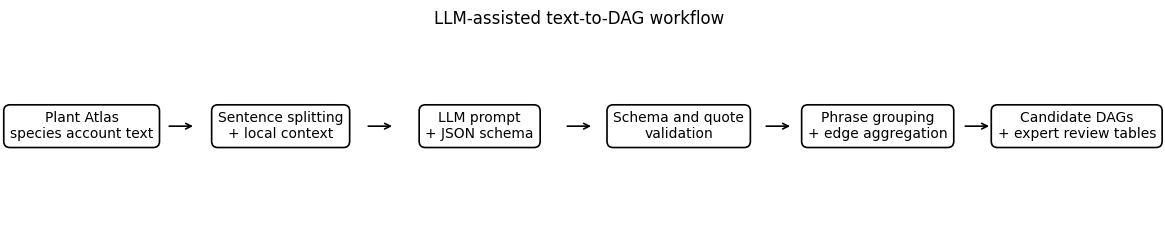

In [4]:
workflow_steps = [
    "Plant Atlas\nspecies account text",
    "Sentence splitting\n+ local context",
    "LLM prompt\n+ JSON schema",
    "Schema and quote\nvalidation",
    "Phrase grouping\n+ edge aggregation",
    "Candidate DAGs\n+ expert review tables",
]

fig, ax = plt.subplots(figsize=(12, 2.4))
ax.axis("off")

x_positions = np.linspace(0.06, 0.94, len(workflow_steps))
for i, (x, label) in enumerate(zip(x_positions, workflow_steps)):
    ax.text(
        x, 0.5, label,
        ha="center", va="center",
        bbox={"boxstyle": "round,pad=0.45", "fc": "white", "ec": "black", "lw": 1.2},
        transform=ax.transAxes,
    )
    if i < len(workflow_steps) - 1:
        ax.annotate(
            "", xy=(x_positions[i + 1] - 0.075, 0.5), xytext=(x + 0.075, 0.5),
            arrowprops={"arrowstyle": "->", "lw": 1.2},
            xycoords=ax.transAxes, textcoords=ax.transAxes,
        )

ax.set_title("LLM-assisted text-to-DAG workflow")
plt.tight_layout()
plt.show()


## Create or load species-account text

The built-in rows below are synthetic. They mimic the structure of local Plant Atlas-style CSV extracts, including fields such as `canonical`, `atlasSpeciesDescription`, `atlasSpeciesBiogeography` and `atlasSpeciesTrends`. They are not copied Plant Atlas account text and should not be quoted as Plant Atlas content.

For a real analysis, set `USE_DEMO_DATA = False` and point `PLANT_ATLAS_DATA_DIR` at local CSV or ZIP files containing the account text to be analysed.


In [5]:
DEMO_SPECIES = [
    {
        "canonical": "Kickxia spuria",
        "vernacular": "Round-leaved Fluellen",
        "atlasSpeciesDescription": (
            "A small annual of arable fields, open disturbed ground and sunny field edges, "
            "most often on light calcareous soils. It can persist where the crop is open "
            "and where cultivation creates bare ground for germination. Dense competitive "
            "vegetation and intensive herbicide use reduce habitat suitability."
        ),
        "atlasSpeciesBiogeography": (
            "A southern-temperate archaeophyte in Britain and the Channel Islands."
        ),
        "atlasSpeciesTrends": (
            "Local populations are most likely to be maintained where arable margins are managed "
            "for scarce plants. Late-summer germination may help some plants escape early-season "
            "herbicide applications, but loss of open cultivated margins remains a pressure."
        ),
    },
    {
        "canonical": "Koenigia islandica",
        "vernacular": "Iceland-purslane",
        "atlasSpeciesDescription": (
            "A tiny annual of wet gravelly flushes, basaltic seepages and open stony ground in "
            "cool upland situations. It depends on short, open vegetation and reliable moisture. "
            "Drying of flushes, trampling that removes the fine substrate, and heavy competition "
            "from taller vegetation can reduce population performance."
        ),
        "atlasSpeciesBiogeography": (
            "A boreal-montane species with a very restricted British range."
        ),
        "atlasSpeciesTrends": (
            "Small colonies may fluctuate between years. Continued seepage, light disturbance and "
            "limited competition are likely to maintain habitat suitability, whereas warmer drier "
            "summers could increase stress on the shallow wet substrates used by the species."
        ),
    },
    {
        "canonical": "Lagurus ovatus",
        "vernacular": "Hare's-tail Grass",
        "atlasSpeciesDescription": (
            "An annual grass of sandy coastal ground, open dunes, walls, roadsides and other dry "
            "disturbed places. It is favoured by bare sand and warm open microsites, and can also "
            "appear from garden escapes. Closed dune grassland and lack of disturbance reduce the "
            "open ground needed for recruitment."
        ),
        "atlasSpeciesBiogeography": (
            "A Mediterranean-Atlantic neophyte that is naturalised in several coastal areas."
        ),
        "atlasSpeciesTrends": (
            "The species appears to be increasing in some sandy coastal habitats. Continued seed "
            "supply from gardens and disturbed urban ground may support local spread, while severe "
            "winter cold may limit establishment inland."
        ),
    },
    {
        "canonical": "Lamium confertum",
        "vernacular": "Northern Dead-nettle",
        "atlasSpeciesDescription": (
            "An annual of cultivated land, disturbed field corners and waste ground. It requires "
            "open soil for germination and is easily overlooked among other dead-nettles. Modern "
            "weed control, autumn-sown dense crops and reduced small-scale cultivation can lower "
            "the chance of plants reaching maturity."
        ),
        "atlasSpeciesBiogeography": (
            "A northern archaeophyte with scattered and often casual records."
        ),
        "atlasSpeciesTrends": (
            "Declines are consistent with the loss of lightly managed cultivated ground. Recent "
            "records may partly reflect targeted recording, so under-recording should be considered "
            "before treating absence as population loss."
        ),
    },
    {
        "canonical": "Larix decidua",
        "vernacular": "European Larch",
        "atlasSpeciesDescription": (
            "A deciduous conifer planted in forestry, shelter-belts and parkland. It regenerates "
            "from seed on disturbed mineral soil, scree and open rocky ground, especially where "
            "light reaches the ground layer. Very dry sites and waterlogged soils are less suitable "
            "for establishment."
        ),
        "atlasSpeciesBiogeography": (
            "A European mountain tree widely planted outside its native range."
        ),
        "atlasSpeciesTrends": (
            "Natural regeneration can follow soil disturbance near planted trees. Disease pressure "
            "from larch pathogens and felling of infected plantations can reduce local abundance, "
            "although continued planting creates new seed sources in some landscapes."
        ),
    },
]

TEXT_COLUMNS_CANDIDATES = [
    "atlasSpeciesDescription",
    "atlasSpeciesTrends",
    "atlasSpeciesBiogeography",
    "description",
    "trends",
    "biogeography",
    "habitat",
    "ecology",
    "management",
]

NAME_COLUMNS_CANDIDATES = [
    "canonical",
    "canonicalName",
    "scientificName",
    "taxonName",
    "name",
    "species",
]


def clean_text(value: Any) -> str:
    """Convert simple HTML-ish text to readable plain text."""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return ""
    text = str(value)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&nbsp;", " ", text)
    text = re.sub(r"&amp;", "&", text)
    text = re.sub(r"&#x2060;", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def find_first_existing(columns: Iterable[str], candidates: list[str]) -> str | None:
    lowered = {str(c).lower(): str(c) for c in columns}
    for candidate in candidates:
        if candidate.lower() in lowered:
            return lowered[candidate.lower()]
    return None


def read_csv_or_zip(path: Path) -> list[tuple[str, pd.DataFrame]]:
    """Read a CSV or every CSV inside a ZIP file."""
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return [(path.name, pd.read_csv(path))]

    if path.suffix.lower() == ".zip":
        out = []
        with zipfile.ZipFile(path, "r") as zf:
            for name in sorted(zf.namelist()):
                if name.lower().endswith(".csv"):
                    with zf.open(name) as f:
                        out.append((f"{path.name}::{name}", pd.read_csv(f)))
        return out

    raise ValueError(f"Unsupported input path: {path}")


def discover_input_paths(data_dir: Path, input_paths: list[Path]) -> list[Path]:
    if input_paths:
        return [Path(p).expanduser().resolve() for p in input_paths]

    data_dir = Path(data_dir).expanduser().resolve()
    if not data_dir.exists():
        return []

    return sorted(list(data_dir.glob("*.csv")) + list(data_dir.glob("*.zip")))


def build_species_text_table() -> pd.DataFrame:
    if USE_DEMO_DATA:
        df = pd.DataFrame(DEMO_SPECIES)
        df["species_id"] = [f"demo_{i:03d}" for i in range(1, len(df) + 1)]
        df["source_file"] = "synthetic_plant_atlas_style_accounts"
        text_columns = [c for c in TEXT_COLUMNS_CANDIDATES if c in df.columns]
        df["source_text"] = df[text_columns].fillna("").agg(" ".join, axis=1).map(clean_text)
        return df[["species_id", "canonical", "source_file", "source_text"]]

    paths = discover_input_paths(DATA_DIR, INPUT_PATHS)
    if not paths:
        raise FileNotFoundError(
            "No input files found. Either set USE_DEMO_DATA=True or place CSV/ZIP files "
            "in PLANT_ATLAS_DATA_DIR."
        )

    rows = []
    for path in paths:
        for source_name, df in read_csv_or_zip(path):
            name_col = find_first_existing(df.columns, NAME_COLUMNS_CANDIDATES)
            text_cols = [c for c in TEXT_COLUMNS_CANDIDATES if c in df.columns]
            if not name_col or not text_cols:
                print(f"Skipping {source_name}: could not identify name/text columns")
                continue

            for idx, row in df.iterrows():
                canonical = clean_text(row.get(name_col, ""))
                parts = [clean_text(row.get(c, "")) for c in text_cols]
                source_text = " ".join(p for p in parts if p)
                if canonical and source_text:
                    rows.append(
                        {
                            "species_id": str(row.get("ddbid", f"{source_name}_{idx}")),
                            "canonical": canonical,
                            "source_file": source_name,
                            "source_text": source_text,
                        }
                    )

    if not rows:
        raise ValueError("No usable species account rows found in the configured input files.")

    out = pd.DataFrame(rows)
    if END_INDEX is not None:
        out = out.iloc[START_INDEX:END_INDEX]
    else:
        out = out.iloc[START_INDEX:]
    return out.reset_index(drop=True)


species_text = build_species_text_table()
species_text.to_csv(OUTPUT_DIR / "species_text_table.csv", index=False)

display(species_text)
print(f"Loaded {len(species_text)} species accounts")


,species_id,canonical,source_file,source_text
0,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,"A small annual of arable fields, open disturbe..."
1,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,"A tiny annual of wet gravelly flushes, basalti..."
2,demo_003,Lagurus ovatus,synthetic_plant_atlas_style_accounts,"An annual grass of sandy coastal ground, open ..."
3,demo_004,Lamium confertum,synthetic_plant_atlas_style_accounts,"An annual of cultivated land, disturbed field ..."
4,demo_005,Larix decidua,synthetic_plant_atlas_style_accounts,"A deciduous conifer planted in forestry, shelt..."


Loaded 5 species accounts


## Data exploration

Before running the LLM, check that the input text looks sensible: how many species are present, how many sentences have been created, and which broad terms appear most often. These simple checks catch common ingestion problems such as selecting the wrong text column or duplicating accounts.


In [6]:
def sentence_split(text: str) -> list[str]:
    text = re.sub(r"\s+", " ", str(text)).strip()
    if not text:
        return []
    # Lightweight splitter suitable for short account prose.
    parts = re.split(r"(?<=[.!?])\s+(?=\[?[A-Z0-9])", text)
    return [p.strip() for p in parts if p.strip()]


sentence_rows = []
for _, row in species_text.iterrows():
    sentences = sentence_split(row["source_text"])
    for sentence_id, sentence in enumerate(sentences):
        prev_start = max(0, sentence_id - CONTEXT_WINDOW_SENTENCES)
        next_end = min(len(sentences), sentence_id + CONTEXT_WINDOW_SENTENCES + 1)

        context_parts = []
        for j in range(prev_start, next_end):
            label = "CURRENT" if j == sentence_id else f"context_{j}"
            context_parts.append(f"[{label}] {sentences[j]}")
        context_text = " ".join(context_parts)

        if len(sentence) > MAX_SENTENCE_CHARS:
            sentence = sentence[:MAX_SENTENCE_CHARS].rsplit(" ", 1)[0] + " ..."

        sentence_rows.append(
            {
                "species_id": row["species_id"],
                "canonical": row["canonical"],
                "source_file": row["source_file"],
                "sentence_id": sentence_id,
                "sentence": sentence,
                "context_text": context_text,
            }
        )

sentences_df = pd.DataFrame(sentence_rows)
sentences_df.to_csv(OUTPUT_DIR / "all_sentences.csv", index=False)

print("Sentence rows:", len(sentences_df))
display(sentences_df.head(10))

Sentence rows: 30


,species_id,canonical,source_file,sentence_id,sentence,context_text
0,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,0,"A small annual of arable fields, open disturbe...","[CURRENT] A small annual of arable fields, ope..."
1,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,1,It can persist where the crop is open and wher...,"[context_0] A small annual of arable fields, o..."
2,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,2,Dense competitive vegetation and intensive her...,[context_1] It can persist where the crop is o...
3,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,3,Local populations are most likely to be mainta...,[context_2] Dense competitive vegetation and i...
4,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,4,Late-summer germination may help some plants e...,[context_3] Local populations are most likely ...
5,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,5,A southern-temperate archaeophyte in Britain a...,[context_4] Late-summer germination may help s...
6,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,0,"A tiny annual of wet gravelly flushes, basalti...",[CURRENT] A tiny annual of wet gravelly flushe...
7,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,1,"It depends on short, open vegetation and relia...",[context_0] A tiny annual of wet gravelly flus...
8,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,2,"Drying of flushes, trampling that removes the ...","[context_1] It depends on short, open vegetati..."
9,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,3,Small colonies may fluctuate between years.,"[context_2] Drying of flushes, trampling that ..."


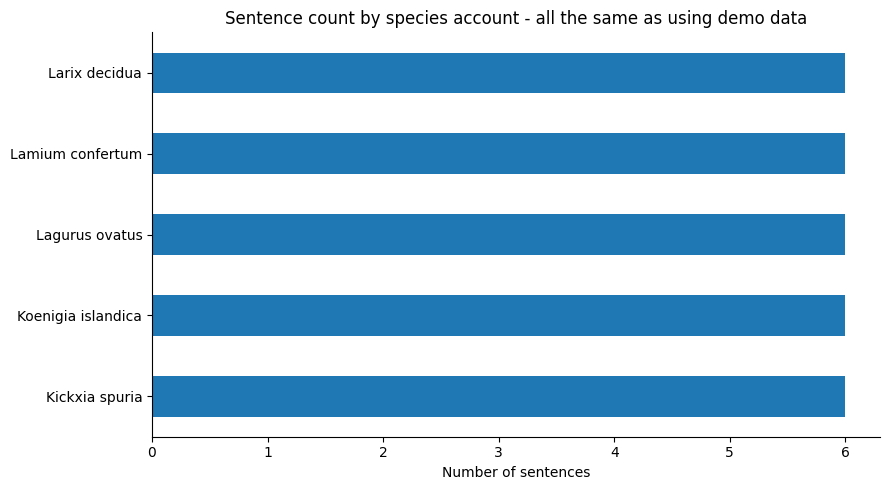

In [7]:
sentence_counts = sentences_df.groupby("canonical").size().sort_values(ascending=True)

ax = sentence_counts.plot(kind="barh")
# set title based on if using dummy data or not
if USE_DEMO_DATA == True:
    ax.set_title("Sentence count by species account - all the same as using demo data")
else:
    ax.set_title("Sentence count by species account")
ax.set_xlabel("Number of sentences")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

,term,count
0,open,10
1,ground,10
2,disturbed,5
3,annual,4
4,reduce,4
5,light,3
6,germination,3
7,vegetation,3
8,some,3
9,loss,3


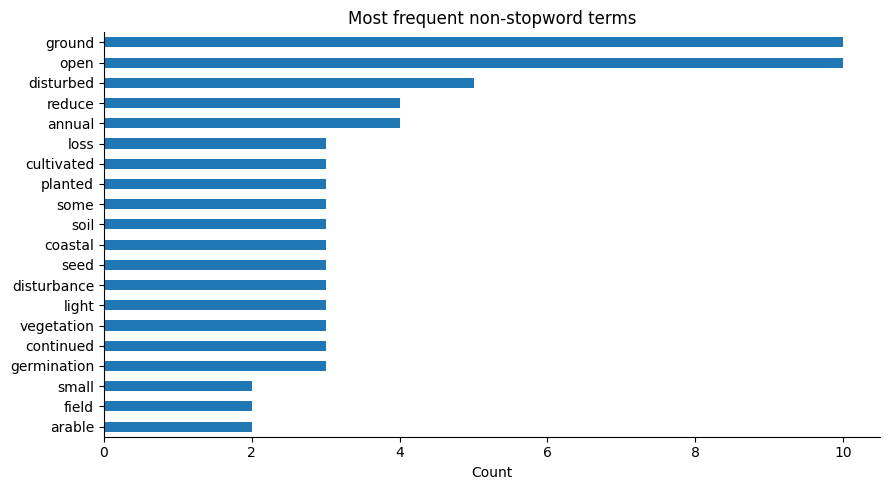

In [8]:
STOPWORDS = {
    "and", "the", "with", "where", "from", "that", "this", "have", "has", "but", "are", "for",
    "can", "may", "into", "its", "their", "species", "plant", "plants", "populations", "local",
    "account", "description", "trend", "trends", "atlasspeciesdescription", "atlasspeciestrends",
}

tokens = []
for text in species_text["source_text"]:
    cleaned = re.sub(r"[^A-Za-z\- ]+", " ", text.lower())
    for token in cleaned.split():
        token = token.strip("-")
        if len(token) > 3 and token not in STOPWORDS:
            tokens.append(token)

common_terms = pd.DataFrame(Counter(tokens).most_common(20), columns=["term", "count"])
display(common_terms)

ax = common_terms.sort_values("count").plot(kind="barh", x="term", y="count", legend=False)
ax.set_title("Most frequent non-stopword terms")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Rule-based sanity check

The next cell is a simple rule-based sanity check. It is not the main method and it is not used as a substitute for the LLM extraction. It provides a quick comparator: if a sentence contains an obvious phrase such as *drainage* or *grazing*, the keyword pass should usually find it.

This is useful when developing prompts because it separates two problems: whether the input text contains relevant ecological phrases at all, and whether the local model extracts them in the desired schema.


In [9]:
SOURCE_TYPE_KEYWORDS = {
    "climate": [
        "drought", "summer drought", "temperature", "warming", "frost", "exposure", "wind exposure", "salt spray"
    ],
    "hydrology": [
        "drainage", "water table", "water tables", "wet", "mire", "bog", "seepage", "river", "flow", "impounded",
        "hydrological"
    ],
    "soil_substrate": [
        "calcareous", "acidic", "base-rich", "peat", "gravel", "shallow soils", "metal-rich", "nutrient-poor"
    ],
    "habitat_structure": [
        "woodland", "hedgebanks", "grassland", "heath", "saltmarsh", "cliffs", "short turf", "open swards",
        "scrub encroachment", "dense secondary canopy", "rank vegetation"
    ],
    "management": [
        "grazing", "coppice", "traditional grazing", "autumn grazing", "management", "abandonment"
    ],
    "land_use": [
        "arable", "agricultural improvement", "ploughing", "reseeding", "coastal development", "roadside"
    ],
    "pollution": [
        "fertiliser", "fertiliser inputs", "nutrient enrichment", "nitrogen deposition", "turbidity", "fertilised"
    ],
    "disturbance": [
        "trampling", "peat cutting", "channel modification", "engineered", "conversion"
    ],
}

POSITIVE_CUES = [
    "favoured by", "favored by", "associated with", "stable in", "increase after", "tolerates",
    "maintain", "maintains", "persist", "persists"
]
NEGATIVE_CUES = [
    "declines", "decline", "reduced", "reduce", "losses", "threatened", "vulnerable",
    "sensitive to", "damage", "displaced", "abandonment"
]

TARGET_RULES = [
    # Prefer a direct abundance target where the sentence is about change, persistence,
    # losses, rarity, maintenance or decline. Habitat and population-performance targets
    # are kept for sentences that are genuinely about mechanism or condition rather than
    # abundance itself.
    ("abundance", [
        "abundance", "decline", "declines", "increase", "increases", "losses", "lost",
        "reduced", "maintained", "maintain", "maintains", "persist", "persists",
        "local populations", "colonies", "rare", "scarce", "common"
    ]),
    ("habitat suitability", [
        "habitat", "sward", "water table", "substrate", "canopy", "light", "turf",
        "germination", "suitability"
    ]),
    ("population performance", ["flowering", "recruitment", "seed", "cover"]),
]


def normalise_node_label(text: str) -> str:
    text = unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode("ascii")
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


DRIVER_LABEL_REPLACEMENTS = {
    "bare ground for germination": "bare_ground",
    "bare ground": "bare_ground",
    "open ground": "open_ground",
    "disturbed ground": "disturbed_ground",
    "open disturbed ground": "disturbed_ground",
    "light calcareous soils": "calcareous_soil",
    "calcareous soils": "calcareous_soil",
    "dense competitive vegetation": "dense_vegetation",
    "competitive vegetation": "dense_vegetation",
    "intensive herbicide use": "herbicide_use",
    "herbicide applications": "herbicide_use",
    "arable margins": "arable_margins",
    "open cultivated margins": "arable_margins",
    "loss of open cultivated margins": "margin_loss",
    "short open swards": "open_sward",
    "short turf": "short_turf",
    "autumn grazing": "autumn_grazing",
    "traditional grazing": "traditional_grazing",
    "scrub encroachment": "scrub",
    "dense secondary canopy": "dense_canopy",
    "water table": "water_table",
    "water tables": "water_table",
    "base-rich seepage": "base_rich_seepage",
    "nitrogen deposition": "nitrogen_dep",
    "nutrient enrichment": "nutrient_enrichment",
    "fertiliser inputs": "fertiliser",
    "summer drought": "summer_drought",
    "salt spray": "salt_spray",
    "coastal development": "coastal_development",
    "agricultural improvement": "agri_improvement",
}

DRIVER_LABEL_STOPWORDS = {
    "a", "an", "the", "and", "or", "of", "for", "to", "by", "with", "where", "which",
    "can", "may", "most", "often", "more", "less", "likely", "local", "plant", "plants",
    "species", "habitat", "habitats", "intensive", "dense", "open"
}


def canonicalise_driver_label(text: str, max_tokens: int = 3) -> str:
    """Create short, graph-friendly driver labels from extracted phrases.

    The evidence table keeps the original phrase in ``source_raw``. This helper
    only shortens the graph node identifier so that the plotted DAG is readable.
    """
    label = normalise_node_label(text)
    if not label:
        return ""

    for phrase, replacement in DRIVER_LABEL_REPLACEMENTS.items():
        if phrase in label:
            return replacement

    tokens = [t for t in re.split(r"[\s\-]+", label) if t and t not in DRIVER_LABEL_STOPWORDS]
    if not tokens:
        tokens = [t for t in re.split(r"[\s\-]+", label) if t]

    # Prefer the most specific end of a noun phrase, e.g. "loss of open cultivated
    # margins" -> "cultivated_margins".
    tokens = tokens[-max_tokens:]
    return "_".join(tokens)


def normalise_target_label(text: str) -> str:
    """Normalise model targets into the small target vocabulary used by the DAG."""
    target = normalise_node_label(text)
    if target in {"abundance", "habitat suitability", "population performance"}:
        return target
    if any(token in target for token in ["decline", "increase", "abundance", "population", "populations", "colonies"]):
        return "abundance"
    if any(token in target for token in ["habitat", "suitability", "condition"]):
        return "habitat suitability"
    if any(token in target for token in ["flowering", "recruitment", "performance", "cover"]):
        return "population performance"
    return "abundance"


def infer_effect(sentence: str) -> str:
    lower = sentence.lower()
    pos = any(cue in lower for cue in POSITIVE_CUES)
    neg = any(cue in lower for cue in NEGATIVE_CUES)
    if pos and not neg:
        return "positive"
    if neg and not pos:
        return "negative"
    if pos and neg:
        return "mixed"
    return "unknown"


def infer_target(sentence: str) -> str:
    lower = sentence.lower()
    for target, cues in TARGET_RULES:
        if any(cue in lower for cue in cues):
            return target
    return "abundance"


def keyword_mentions(sentence: str) -> list[tuple[str, str]]:
    lower = sentence.lower()
    matches = []
    for source_type, keywords in SOURCE_TYPE_KEYWORDS.items():
        for keyword in keywords:
            if re.search(r"\b" + re.escape(keyword.lower()) + r"\b", lower):
                matches.append((source_type, keyword))
    # Prefer longer phrases first and deduplicate.
    matches = sorted(matches, key=lambda x: len(x[1]), reverse=True)
    seen = set()
    out = []
    for source_type, keyword in matches:
        key = (source_type, keyword.lower())
        if key not in seen:
            seen.add(key)
            out.append((source_type, keyword))
    return out


def deterministic_extract_edges(sentences: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in sentences.iterrows():
        sentence = row["sentence"]
        matches = keyword_mentions(sentence)
        if not matches:
            continue

        effect = infer_effect(sentence)
        target = infer_target(sentence)

        for source_type, keyword in matches:
            source_raw = keyword
            source_canonical = normalise_node_label(source_raw)

            confidence = 0.55
            if effect != "unknown":
                confidence += 0.15
            if len(keyword.split()) > 1:
                confidence += 0.05

            rows.append(
                {
                    "species_id": row["species_id"],
                    "canonical": row["canonical"],
                    "source_file": row["source_file"],
                    "sentence_id": int(row["sentence_id"]),
                    "source_raw": source_raw,
                    "source_canonical": canonicalise_driver_label(source_raw),
                    "source_type": source_type,
                    "target_canonical": target,
                    "effect": effect,
                    "confidence": round(min(confidence, 0.90), 2),
                    "evidence_quote": sentence,
                    "extraction_method": "deterministic_keyword_demo",
                }
            )

    return pd.DataFrame(rows)


baseline_edges_df = deterministic_extract_edges(sentences_df)
baseline_edges_df.to_csv(OUTPUT_DIR / "baseline_deterministic_candidate_edges.csv", index=False)

print("Baseline deterministic candidate edges:", len(baseline_edges_df))
display(baseline_edges_df.head(15))

Baseline deterministic candidate edges: 8


,species_id,canonical,source_file,sentence_id,source_raw,source_canonical,source_type,target_canonical,effect,confidence,evidence_quote,extraction_method
0,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,0,calcareous,calcareous,soil_substrate,habitat suitability,unknown,0.55,"A small annual of arable fields, open disturbe...",deterministic_keyword_demo
1,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,0,arable,arable,land_use,habitat suitability,unknown,0.55,"A small annual of arable fields, open disturbe...",deterministic_keyword_demo
2,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,3,arable,arable,land_use,abundance,positive,0.70,Local populations are most likely to be mainta...,deterministic_keyword_demo
3,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,0,wet,wet,hydrology,abundance,unknown,0.55,"A tiny annual of wet gravelly flushes, basalti...",deterministic_keyword_demo
4,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,2,trampling,trampling,disturbance,habitat suitability,negative,0.70,"Drying of flushes, trampling that removes the ...",deterministic_keyword_demo
5,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,4,seepage,seepage,hydrology,abundance,positive,0.70,"Continued seepage, light disturbance and limit...",deterministic_keyword_demo
6,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,4,wet,wet,hydrology,abundance,positive,0.70,"Continued seepage, light disturbance and limit...",deterministic_keyword_demo
7,demo_003,Lagurus ovatus,synthetic_plant_atlas_style_accounts,2,grassland,grassland,habitat_structure,population performance,negative,0.70,Closed dune grassland and lack of disturbance ...,deterministic_keyword_demo


## Local LLM evidence extraction

This is the main extraction step. Each sentence is sent to the local model with a short neighbouring context window and a constrained JSON schema. The model is asked for candidate driver relationships only when the sentence contains evidence for a factor that may affect habitat suitability, population performance or abundance.

The prompt is deliberately narrow. The model is not asked to write a causal diagram or summarise a species account. It only proposes sentence-grounded candidate rows that can be validated and reviewed later.


In [10]:
LLM_SCHEMA = {
    "edges": [
        {
            "source_raw": "exact phrase copied from the current sentence",
            "source_type": (
                "climate|hydrology|soil_substrate|habitat_structure|disturbance|"
                "management|land_use|biotic_interaction|disease_pathogen|pollution|"
                "topography|other"
            ),
            "target_canonical": "abundance|habitat suitability|population performance",
            "effect": "positive|negative|mixed|unknown",
            "confidence": 0.70,
            "evidence_quote": "short quote copied from the current sentence",
        }
    ]
}


def make_llm_prompt(canonical: str, sentence_id: int, sentence: str, context_text: str) -> str:
    """Create a narrow, evidence-grounded prompt for one sentence."""
    return f"""
You are helping ecologists convert Plant Atlas species-account prose into
reviewable candidate causal-graph edges.

Species: {canonical}
Sentence ID: {sentence_id}

CURRENT SENTENCE:
{sentence}

NEIGHBOURING CONTEXT FOR DISAMBIGUATION ONLY:
{context_text}

Task:
Extract candidate ecological driver relationships from the CURRENT SENTENCE.
Use only evidence stated in the CURRENT SENTENCE. Do not infer from general
knowledge. Ignore dates, pure locations, taxonomic notes, recording history and
introduction-history statements unless they are directly linked to abundance,
habitat suitability or population performance.

Return one JSON object and nothing else. No markdown. No explanation. No trailing
text. Keep source_raw labels short so that they can be read on a graph. If the current sentence contains no relevant relationship, return exactly:
{{"edges": []}}

Definitions:
- source_raw: an exact, short driver phrase copied from the CURRENT SENTENCE. Prefer compact noun phrases of one to four words, for example "grazing", "bare ground", "calcareous soils" or "herbicide use". Do not use a whole clause as the source.
- source_type: one of climate, hydrology, soil_substrate, habitat_structure,
  disturbance, management, land_use, biotic_interaction, disease_pathogen,
  pollution, topography or other.
- target_canonical: one of abundance, habitat suitability or population performance. Use abundance when the sentence says the driver maintains, increases, reduces, threatens, explains losses of, or is associated with local populations, colonies, rarity, decline, persistence or abundance. Use habitat suitability only when the sentence is mainly about habitat condition. Use population performance for flowering, recruitment, seed set or vigour.
- effect: positive means the source tends to increase or maintain the target;
  negative means it tends to reduce the target; mixed means both are stated;
  unknown means the relationship is stated but direction is unclear.
- confidence: a number from 0 to 1.
- evidence_quote: a short quote copied from the CURRENT SENTENCE.

JSON schema example:
{json.dumps(LLM_SCHEMA, indent=2)}
""".strip()


def preview_prompt(row_number: int = 0) -> None:
    """Print one prompt so reviewers can inspect exactly what the LLM sees."""
    row = sentences_df.iloc[row_number]
    print(make_llm_prompt(row["canonical"], int(row["sentence_id"]), row["sentence"], row["context_text"]))


preview_prompt(0)


You are helping ecologists convert Plant Atlas species-account prose into
reviewable candidate causal-graph edges.

Species: Kickxia spuria
Sentence ID: 0

CURRENT SENTENCE:
A small annual of arable fields, open disturbed ground and sunny field edges, most often on light calcareous soils.

NEIGHBOURING CONTEXT FOR DISAMBIGUATION ONLY:
[CURRENT] A small annual of arable fields, open disturbed ground and sunny field edges, most often on light calcareous soils. [context_1] It can persist where the crop is open and where cultivation creates bare ground for germination.

Task:
Extract candidate ecological driver relationships from the CURRENT SENTENCE.
Use only evidence stated in the CURRENT SENTENCE. Do not infer from general
knowledge. Ignore dates, pure locations, taxonomic notes, recording history and
introduction-history statements unless they are directly linked to abundance,
habitat suitability or population performance.

Return one JSON object and nothing else. No markdown. No expla

In [11]:
RAW_EDGE_COLUMNS = [
    "species_id",
    "canonical",
    "source_file",
    "sentence_id",
    "source_raw",
    "source_canonical",
    "source_type",
    "target_canonical",
    "effect",
    "confidence",
    "evidence_quote",
    "extraction_method",
    "llm_error",
]

LLM_AUDIT_COLUMNS = [
    "species_id",
    "canonical",
    "source_file",
    "sentence_id",
    "parse_status",
    "n_candidate_edges",
    "response_hash",
    "diagnostic_note",
]

AGG_EDGE_COLUMNS = [
    "species_id",
    "canonical",
    "source_canonical",
    "target_canonical",
    "effect",
    "source_types",
    "source_raw_examples",
    "source_canonical_examples",
    "semantic_cluster_ids",
    "n_evidence_sentences",
    "sentence_ids",
    "evidence_quotes",
    "mean_confidence",
    "max_confidence",
    "extraction_methods",
    "edge_origin",
    "assumption",
]

DAG_DIAGNOSTIC_COLUMNS = [
    "species_id",
    "canonical",
    "n_nodes",
    "n_edges",
    "is_dag",
    "example_cycles",
]

NODE_COLUMNS = [
    "species_id",
    "canonical",
    "node",
    "node_type",
]


def ensure_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Return a copy with all expected columns present, preserving row order."""
    out = df.copy()
    for col in columns:
        if col not in out.columns:
            out[col] = np.nan
    return out[columns + [c for c in out.columns if c not in columns]]


def coerce_json_object(text: str) -> dict[str, Any]:
    """Parse a JSON object from small-model output.

    The prompt asks for JSON only. In practice, small local models can still add
    a short preamble, markdown fence or dangling comma. The parser repairs those
    simple cases, then returns a normalised object with an ``edges`` list.
    """
    cleaned = str(text).strip()
    cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned)
    cleaned = re.sub(r"\s*```$", "", cleaned)

    # Prefer the whole response, but fall back to the outermost JSON object.
    candidate = cleaned
    if "{" in cleaned and "}" in cleaned:
        candidate = cleaned[cleaned.find("{"): cleaned.rfind("}") + 1]

    # A few deterministic repairs that do not invent content.
    candidate = candidate.replace("\u201c", '"').replace("\u201d", '"')
    candidate = re.sub(r",\s*([}\]])", r"\1", candidate)

    obj = json.loads(candidate)

    if not isinstance(obj, dict):
        raise ValueError("LLM response was valid JSON but not a JSON object")
    if "edges" not in obj or obj["edges"] is None:
        obj["edges"] = []
    if not isinstance(obj["edges"], list):
        raise ValueError("LLM response field 'edges' was not a list")
    return obj


def safe_coerce_json_object(text: str) -> tuple[dict[str, Any], str]:
    """Parse an LLM response without creating visible notebook errors.

    If parsing still fails after deterministic repairs, the sentence contributes
    no candidate edge. The diagnostic is written to ``llm_extraction_audit.csv``
    rather than displayed in the main rendered notebook.
    """
    try:
        return coerce_json_object(text), "parsed"
    except Exception:
        return {"edges": []}, "unparsed_empty"


_TRANSFORMERS_PIPELINE = None


def validate_local_model_path(model_path: Path) -> None:
    """Fail early unless a local Hugging Face-compatible model directory is present."""
    model_path = Path(model_path)

    if not model_path.exists():
        raise FileNotFoundError(
            f"MODEL_PATH does not exist: {model_path}. "
            "Set MODEL_PATH to a local Hugging Face-compatible instruction model directory, "
            "for example: export MODEL_PATH=../models/qwen2.5-3b-instruct"
        )

    if not model_path.is_dir():
        raise NotADirectoryError(
            f"MODEL_PATH is not a directory: {model_path}. "
            "Set MODEL_PATH to the directory containing the local model files."
        )

    present = {p.name for p in model_path.iterdir()}
    if "config.json" not in present:
        raise FileNotFoundError(
            f"MODEL_PATH is missing config.json: {model_path}. "
            "This does not look like a Hugging Face model directory."
        )

    tokenizer_files = {"tokenizer.json", "tokenizer.model", "vocab.json", "merges.txt"}
    if not (present & tokenizer_files):
        raise FileNotFoundError(
            f"MODEL_PATH is missing recognisable tokenizer files: {model_path}. "
            "Expected one of tokenizer.json, tokenizer.model, vocab.json or merges.txt."
        )

    weight_patterns = ["*.safetensors", "*.bin", "*.pt"]
    if not any(model_path.glob(pattern) for pattern in weight_patterns):
        raise FileNotFoundError(
            f"MODEL_PATH does not contain local model weights: {model_path}. "
            "Expected files such as *.safetensors or *.bin. "
            "The notebook intentionally does not download weights during execution."
        )


def get_transformers_pipeline():
    """Load a local Hugging Face Transformers text-generation pipeline once."""
    global _TRANSFORMERS_PIPELINE

    if _TRANSFORMERS_PIPELINE is not None:
        return _TRANSFORMERS_PIPELINE

    validate_local_model_path(MODEL_PATH)

    try:
        import torch
        from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline
    except ImportError as exc:
        raise ImportError(
            "Install torch, transformers, accelerate and bitsandbytes for local inference."
        ) from exc

    print(f"Loading local LLM from: {MODEL_PATH}")
    print("This one-off model-load step can take a few minutes on first run.")
    print(f"4-bit quantised loading: {LLM_LOAD_IN_4BIT}")

    tokenizer = AutoTokenizer.from_pretrained(
        LLM_MODEL,
        local_files_only=True,
        trust_remote_code=False,
    )
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    model_kwargs = {
        "device_map": LLM_DEVICE_MAP,
        "local_files_only": True,
        "trust_remote_code": False,
    }

    if LLM_LOAD_IN_4BIT:
        compute_dtype = getattr(torch, LLM_4BIT_COMPUTE_DTYPE)
        model_kwargs["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type=LLM_4BIT_QUANT_TYPE,
            bnb_4bit_use_double_quant=LLM_4BIT_USE_DOUBLE_QUANT,
            bnb_4bit_compute_dtype=compute_dtype,
        )
    else:
        if LLM_TORCH_DTYPE == "auto":
            model_kwargs["torch_dtype"] = "auto"
        else:
            model_kwargs["torch_dtype"] = getattr(torch, LLM_TORCH_DTYPE)

    model = AutoModelForCausalLM.from_pretrained(LLM_MODEL, **model_kwargs)
    model.eval()

    # Keep generation settings explicit in the extraction call below. Some model
    # repositories define default max_length/min_length values that are harmless
    # but noisy in rendered notebooks when max_new_tokens is also supplied.
    model.generation_config.max_length = None
    model.generation_config.min_length = None
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.eos_token_id

    _TRANSFORMERS_PIPELINE = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
    )
    return _TRANSFORMERS_PIPELINE


def make_model_input(prompt: str, tokenizer) -> str:
    """Apply the model chat template where available, otherwise use a plain prompt."""
    system_message = (
        "You extract sentence-grounded ecological evidence as strict JSON. "
        "Do not add evidence that is not stated in the supplied sentence. "
        "Return one JSON object only. If no relationship is present, return {\"edges\": []}."
    )

    if getattr(tokenizer, "chat_template", None):
        return tokenizer.apply_chat_template(
            [
                {"role": "system", "content": system_message},
                {"role": "user", "content": prompt},
            ],
            tokenize=False,
            add_generation_prompt=True,
        )
    return f"{system_message}\n\n{prompt}\n\nJSON:"


def truncate_model_input(model_input: str, tokenizer) -> str:
    """Keep prompts within a fixed token budget before generation."""
    token_ids = tokenizer.encode(model_input, add_special_tokens=False)
    if len(token_ids) <= LLM_MAX_INPUT_TOKENS:
        return model_input
    token_ids = token_ids[-LLM_MAX_INPUT_TOKENS:]
    return tokenizer.decode(token_ids, skip_special_tokens=True)


def batched(items: list[Any], batch_size: int) -> list[list[Any]]:
    """Yield fixed-size batches."""
    return [items[i: i + batch_size] for i in range(0, len(items), batch_size)]


def unpack_pipeline_output(output: Any) -> str:
    """Handle slightly different pipeline return shapes across transformers versions."""
    if isinstance(output, list) and output and isinstance(output[0], dict):
        return output[0].get("generated_text", "")
    if isinstance(output, dict):
        return output.get("generated_text", "")
    return str(output)


def call_transformers_json_batch(prompts: list[str]) -> list[tuple[dict[str, Any], str, str]]:
    """Run local Transformers generation for a batch and parse responses safely."""
    pipe = get_transformers_pipeline()
    tokenizer = pipe.tokenizer

    model_inputs = [truncate_model_input(make_model_input(prompt, tokenizer), tokenizer) for prompt in prompts]

    generation_kwargs = {
        "max_new_tokens": LLM_MAX_NEW_TOKENS,
        "do_sample": LLM_TEMPERATURE > 0,
        "return_full_text": False,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }
    if LLM_TEMPERATURE > 0:
        generation_kwargs["temperature"] = LLM_TEMPERATURE

    # Some transformers/bitsandbytes versions emit repeated generation-configuration
    # messages to stderr even when settings are harmless. Suppress that noise
    # in the rendered notebook; the extraction audit records parse status.
    with warnings.catch_warnings(), contextlib.redirect_stderr(io.StringIO()):
        warnings.simplefilter("ignore")
        outputs = pipe(model_inputs, batch_size=LLM_BATCH_SIZE, **generation_kwargs)

    generated_texts = [unpack_pipeline_output(output) for output in outputs]

    parsed = []
    for generated_text in generated_texts:
        payload, parse_status = safe_coerce_json_object(generated_text)
        parsed.append((payload, parse_status, generated_text))
    return parsed


def normalise_llm_edges(payload: dict[str, Any], sentence_row: pd.Series) -> list[dict[str, Any]]:
    """Convert provider JSON into the notebook's dataframe schema."""
    out = []
    for item in payload.get("edges", []):
        if not isinstance(item, dict):
            continue

        source_raw = str(item.get("source_raw", "")).strip()
        if not source_raw:
            continue

        source_type = str(item.get("source_type", "other")).strip()
        target = normalise_target_label(str(item.get("target_canonical", "abundance")).strip())
        effect = str(item.get("effect", "unknown")).strip().lower()
        quote = str(item.get("evidence_quote", "")).strip()
        if not quote:
            quote = str(sentence_row["sentence"]).strip()

        try:
            confidence = float(item.get("confidence", 0.5))
        except (TypeError, ValueError):
            confidence = 0.5

        out.append(
            {
                "species_id": sentence_row["species_id"],
                "canonical": sentence_row["canonical"],
                "source_file": sentence_row["source_file"],
                "sentence_id": int(sentence_row["sentence_id"]),
                "source_raw": source_raw,
                "source_canonical": canonicalise_driver_label(source_raw),
                "source_type": source_type,
                "target_canonical": target,
                "effect": effect,
                "confidence": round(max(0.0, min(confidence, 1.0)), 2),
                "evidence_quote": quote,
                "extraction_method": "llm_transformers",
                "llm_error": np.nan,
            }
        )
    return out


def extract_edges_with_llm(sentences: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run the required local LLM over sentence rows, with batching and progress reporting."""
    try:
        from tqdm.auto import tqdm
    except ImportError:
        tqdm = lambda x, **kwargs: x

    sentence_iter = sentences.copy()
    if LLM_MAX_SENTENCES is not None:
        sentence_iter = sentence_iter.head(int(LLM_MAX_SENTENCES))

    sentence_rows = [row for _, row in sentence_iter.iterrows()]
    prompts = [
        make_llm_prompt(
            row["canonical"],
            int(row["sentence_id"]),
            row["sentence"],
            row["context_text"],
        )
        for row in sentence_rows
    ]

    print(f"Prepared {len(prompts)} sentence-level LLM calls.")
    print(
        f"Batch size: {LLM_BATCH_SIZE}; max_new_tokens: {LLM_MAX_NEW_TOKENS}; max_input_tokens: {LLM_MAX_INPUT_TOKENS}")

    # Pre-flight model loading is deliberate. If MODEL_PATH or 4-bit setup is
    # wrong, fail here with a setup error rather than writing non-LLM outputs.
    get_transformers_pipeline()

    rows = []
    audit_rows = []
    for row_batch, prompt_batch in tqdm(
            zip(batched(sentence_rows, LLM_BATCH_SIZE), batched(prompts, LLM_BATCH_SIZE)),
            total=(len(prompts) + LLM_BATCH_SIZE - 1) // LLM_BATCH_SIZE,
            desc="LLM extraction batches",
    ):
        parsed_payloads = call_transformers_json_batch(prompt_batch)
        for row, (payload, parse_status, generated_text) in zip(row_batch, parsed_payloads):
            new_edges = normalise_llm_edges(payload, row)
            rows.extend(new_edges)
            audit_rows.append(
                {
                    "species_id": row["species_id"],
                    "canonical": row["canonical"],
                    "source_file": row["source_file"],
                    "sentence_id": int(row["sentence_id"]),
                    "parse_status": parse_status,
                    "n_candidate_edges": len(new_edges),
                    "response_hash": hashlib.sha256(str(generated_text).encode("utf-8")).hexdigest()[:12],
                    "diagnostic_note": "" if parse_status == "parsed" else "response did not parse as JSON after deterministic cleanup; treated as no candidate edge",
                }
            )

    edge_df = ensure_columns(pd.DataFrame(rows), RAW_EDGE_COLUMNS)
    audit_df = ensure_columns(pd.DataFrame(audit_rows), LLM_AUDIT_COLUMNS)
    return edge_df, audit_df


raw_edges_df, llm_extraction_audit_df = extract_edges_with_llm(sentences_df)
raw_edges_df.to_csv(OUTPUT_DIR / "all_raw_candidate_edges.csv", index=False)
llm_extraction_audit_df.to_csv(OUTPUT_DIR / "llm_extraction_audit.csv", index=False)

n_sentences_processed = len(llm_extraction_audit_df)
n_sentences_with_edges = int((llm_extraction_audit_df["n_candidate_edges"] > 0).sum()) if n_sentences_processed else 0

print("LLM-assisted candidate edges:", len(raw_edges_df))
print("Sentences processed:", n_sentences_processed)
print("Sentences returning at least one candidate edge:", n_sentences_with_edges)

if raw_edges_df.empty:
    print("No candidate edges were extracted for this input.")
else:
    display(raw_edges_df.head(10))

if SHOW_EXTRACTION_DIAGNOSTICS:
    display(llm_extraction_audit_df)


Prepared 30 sentence-level LLM calls.
Batch size: 1; max_new_tokens: 192; max_input_tokens: 1536
Loading local LLM from: ../models/qwen2.5-3b-instruct
This one-off model-load step can take a few minutes on first run.
4-bit quantised loading: True


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

LLM extraction batches:   0%|          | 0/30 [00:00<?, ?it/s]

LLM-assisted candidate edges: 37
Sentences processed: 30
Sentences returning at least one candidate edge: 29


,species_id,canonical,source_file,sentence_id,source_raw,source_canonical,source_type,target_canonical,effect,confidence,evidence_quote,extraction_method,llm_error
0,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,0,light calcareous soils,calcareous_soil,soil_substrate,abundance,positive,1.0,most often on light calcareous soils.,llm_transformers,NaN
1,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,1,crop,crop,land_use,habitat suitability,positive,1.0,It can persist where the crop is open and wher...,llm_transformers,NaN
2,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,1,cultivation,cultivation,disturbance,habitat suitability,positive,1.0,It can persist where the crop is open and wher...,llm_transformers,NaN
3,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,2,dense competitive vegetation,dense_vegetation,habitat_structure,habitat suitability,negative,1.0,Dense competitive vegetation and intensive her...,llm_transformers,NaN
4,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,2,intensive herbicide use,herbicide_use,management,habitat suitability,negative,1.0,Dense competitive vegetation and intensive her...,llm_transformers,NaN
5,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,3,arable margins,arable_margins,habitat structure,habitat suitability,positive,1.0,Local populations are most likely to be mainta...,llm_transformers,NaN
6,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,4,loss of open cultivated margins,arable_margins,disturbance,abundance,negative,1.0,but loss of open cultivated margins remains a ...,llm_transformers,NaN
7,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,5,southern-temperate,southern_temperate,climate,abundance,positive,1.0,A southern-temperate archaeophyte in Britain a...,llm_transformers,NaN
8,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,0,cool upland situations,cool_upland_situations,habitat_structure,habitat suitability,positive,1.0,in cool upland situations.,llm_transformers,NaN
9,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,1,"short, open vegetation",short_vegetation,habitat_structure,habitat suitability,positive,1.0,"It depends on short, open vegetation and relia...",llm_transformers,NaN


## Inspect local LLM extraction coverage

The first check is whether the model produced candidate edges, how many sentences failed parsing or generation, and how many candidate edges were returned per species. This is a diagnostic step, not evidence that the extracted edges are correct.

For a real analysis, inspect the error rate before moving on. A few failures may be acceptable if the review table still contains useful evidence, but a high failure rate usually means the prompt, model or token limits need attention.


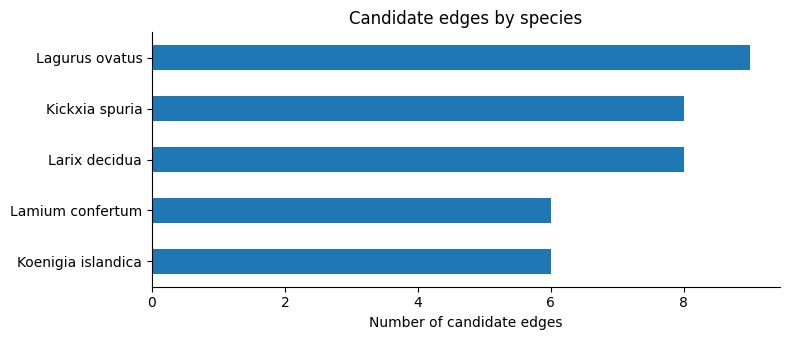

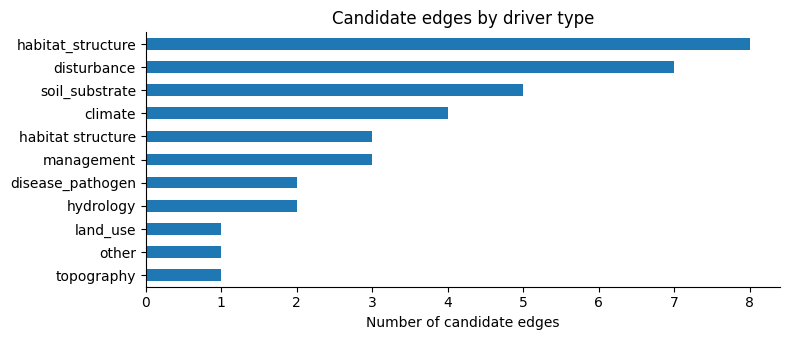

,source_type,confidence
0,disease_pathogen,0.850000
1,topography,0.900000
2,disturbance,0.985714
3,climate,1.000000
4,habitat_structure,1.000000
5,hydrology,1.000000
6,land_use,1.000000
7,habitat structure,1.000000
8,management,1.000000
9,other,1.000000


In [12]:
if raw_edges_df.empty:
    print("No candidate edges were extracted.")
else:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    species_counts = raw_edges_df["canonical"].value_counts().sort_values()
    species_counts.plot(kind="barh", ax=ax)
    ax.set_title("Candidate edges by species")
    ax.set_xlabel("Number of candidate edges")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 3.5))
    type_counts = raw_edges_df["source_type"].value_counts().sort_values()
    type_counts.plot(kind="barh", ax=ax)
    ax.set_title("Candidate edges by driver type")
    ax.set_xlabel("Number of candidate edges")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    confidence_by_type = (
        raw_edges_df.groupby("source_type", dropna=False)["confidence"]
        .mean()
        .sort_values()
        .reset_index()
    )
    display(confidence_by_type)


## Validate candidate edges

The validation step checks that each proposed row has the required fields, allowed values and a quote that can be linked back to the source sentence. Rows that fail validation are retained with flags rather than hidden.

This keeps the workflow auditable: the review table shows both the proposed relationship and the reason it should be treated with caution.


In [13]:
VALID_TARGETS = {"abundance", "habitat suitability", "population performance"}
VALID_EFFECTS = {"positive", "negative", "mixed", "unknown"}
EXTERNAL_DRIVER_TYPES = {
    "climate",
    "hydrology",
    "soil_substrate",
    "habitat_structure",
    "disturbance",
    "management",
    "land_use",
    "biotic_interaction",
    "disease_pathogen",
    "pollution",
    "topography",
    "other",
}

NON_DRIVER_PATTERNS = [
    r"\b\d{4}\b",
    r"\bfirst recorded\b",
    r"\bintroduced\b",
    r"\bnative\b",
    r"\barchaeophyte\b",
    r"\bneophyte\b",
]


def validate_edge(row: pd.Series) -> dict[str, Any]:
    reasons = []
    warnings = []

    source = str(row.get("source_raw", "")).strip()
    quote = str(row.get("evidence_quote", "")).strip()
    target = str(row.get("target_canonical", "")).strip().lower()
    effect = str(row.get("effect", "")).strip().lower()
    source_type = str(row.get("source_type", "")).strip().lower()

    if not source:
        reasons.append("missing_source_phrase")
    if not quote:
        reasons.append("missing_evidence_quote")
    if target not in VALID_TARGETS:
        reasons.append("invalid_target")
    if effect not in VALID_EFFECTS:
        reasons.append("invalid_effect")
    if source_type not in EXTERNAL_DRIVER_TYPES:
        reasons.append("invalid_source_type")

    lower_source = source.lower()
    lower_quote = quote.lower()
    if source and lower_source not in lower_quote:
        warnings.append("source_phrase_not_exactly_in_quote")

    if any(re.search(pattern, lower_source) for pattern in NON_DRIVER_PATTERNS):
        reasons.append("likely_non_driver_source")

    accepted_as_evidence = not reasons
    accepted_for_environmental_dag = accepted_as_evidence and source_type != "other"

    return {
        "accepted_as_evidence": accepted_as_evidence,
        "accepted_for_environmental_dag": accepted_for_environmental_dag,
        "validation_reasons": "|".join(reasons),
        "validation_warnings": "|".join(warnings),
    }


if raw_edges_df.empty:
    validated_edges_df = raw_edges_df.copy()
else:
    validation = raw_edges_df.apply(validate_edge, axis=1, result_type="expand")
    validated_edges_df = pd.concat([raw_edges_df.reset_index(drop=True), validation.reset_index(drop=True)], axis=1)

validated_edges_df.to_csv(OUTPUT_DIR / "all_candidate_edges_validated.csv", index=False)

print("Validated candidate edges:", len(validated_edges_df))
if len(validated_edges_df):
    display(validated_edges_df.head(15))
    display(validated_edges_df["accepted_for_environmental_dag"].value_counts(dropna=False).rename("count"))
else:
    print("No candidate edges were produced.")

Validated candidate edges: 37


,species_id,canonical,source_file,sentence_id,source_raw,source_canonical,source_type,target_canonical,effect,confidence,evidence_quote,extraction_method,llm_error,accepted_as_evidence,accepted_for_environmental_dag,validation_reasons,validation_warnings
0,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,0,light calcareous soils,calcareous_soil,soil_substrate,abundance,positive,1.0,most often on light calcareous soils.,llm_transformers,NaN,True,True,,
1,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,1,crop,crop,land_use,habitat suitability,positive,1.0,It can persist where the crop is open and wher...,llm_transformers,NaN,True,True,,
2,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,1,cultivation,cultivation,disturbance,habitat suitability,positive,1.0,It can persist where the crop is open and wher...,llm_transformers,NaN,True,True,,
3,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,2,dense competitive vegetation,dense_vegetation,habitat_structure,habitat suitability,negative,1.0,Dense competitive vegetation and intensive her...,llm_transformers,NaN,True,True,,
4,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,2,intensive herbicide use,herbicide_use,management,habitat suitability,negative,1.0,Dense competitive vegetation and intensive her...,llm_transformers,NaN,True,True,,
5,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,3,arable margins,arable_margins,habitat structure,habitat suitability,positive,1.0,Local populations are most likely to be mainta...,llm_transformers,NaN,False,False,invalid_source_type,
6,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,4,loss of open cultivated margins,arable_margins,disturbance,abundance,negative,1.0,but loss of open cultivated margins remains a ...,llm_transformers,NaN,True,True,,
7,demo_001,Kickxia spuria,synthetic_plant_atlas_style_accounts,5,southern-temperate,southern_temperate,climate,abundance,positive,1.0,A southern-temperate archaeophyte in Britain a...,llm_transformers,NaN,True,True,,
8,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,0,cool upland situations,cool_upland_situations,habitat_structure,habitat suitability,positive,1.0,in cool upland situations.,llm_transformers,NaN,True,True,,
9,demo_002,Koenigia islandica,synthetic_plant_atlas_style_accounts,1,"short, open vegetation",short_vegetation,habitat_structure,habitat suitability,positive,1.0,"It depends on short, open vegetation and relia...",llm_transformers,NaN,True,True,,


accepted_for_environmental_dag
True     33
False     4
Name: count, dtype: int64

## Group similar driver phrases

The LLM extracts phrases as they appear in the sentence, so the same ecological idea may appear in several wordings. For example, `fertiliser inputs`, `high fertiliser inputs` and `fertilised grassland` should often be reviewed together. This section uses a lightweight token-overlap approach to create provisional phrase clusters.

For a larger analysis, this step could be replaced by embedding-based clustering or an expert-curated vocabulary. A transparent string-based method is used here because it is easy to inspect.


In [14]:
def phrase_tokens(text: str) -> set[str]:
    text = normalise_node_label(text)
    return {t for t in text.split() if len(t) > 2}


def jaccard(a: set[str], b: set[str]) -> float:
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


def connected_components_from_pairs(labels: list[str], threshold: float) -> dict[str, int]:
    graph = nx.Graph()
    graph.add_nodes_from(labels)
    token_map = {label: phrase_tokens(label) for label in labels}

    for i, a in enumerate(labels):
        for b in labels[i + 1:]:
            if jaccard(token_map[a], token_map[b]) >= threshold:
                graph.add_edge(a, b)

    component_id = {}
    for idx, component in enumerate(nx.connected_components(graph), start=1):
        for label in component:
            component_id[label] = idx
    return component_id


dag_edges = validated_edges_df[validated_edges_df.get("accepted_for_environmental_dag", False).astype(bool)].copy()

if dag_edges.empty:
    clustered_edges_df = dag_edges.copy()
    cluster_table = pd.DataFrame(columns=["source_type", "semantic_cluster_id", "semantic_cluster_label", "members"])
else:
    clustered_parts = []
    cluster_rows = []

    for source_type, group in dag_edges.groupby("source_type"):
        labels = sorted(group["source_canonical"].dropna().unique())
        component_ids = connected_components_from_pairs(labels, PHRASE_SIMILARITY_THRESHOLD)

        label_to_cluster = {}
        for cluster_id in sorted(set(component_ids.values())):
            members = sorted([label for label, cid in component_ids.items() if cid == cluster_id])
            # Use the shortest member as a readable provisional label.
            cluster_label = sorted(members, key=lambda x: (len(x), x))[0]
            semantic_cluster_id = f"{source_type}_{cluster_id:03d}"
            for member in members:
                label_to_cluster[member] = (semantic_cluster_id, cluster_label)
            cluster_rows.append(
                {
                    "source_type": source_type,
                    "semantic_cluster_id": semantic_cluster_id,
                    "semantic_cluster_label": cluster_label,
                    "members": "; ".join(members),
                }
            )

        tmp = group.copy()
        tmp["semantic_cluster_id"] = tmp["source_canonical"].map(lambda x: label_to_cluster[x][0])
        tmp["semantic_cluster_label"] = tmp["source_canonical"].map(lambda x: label_to_cluster[x][1])
        clustered_parts.append(tmp)

    clustered_edges_df = pd.concat(clustered_parts, ignore_index=True)
    cluster_table = pd.DataFrame(cluster_rows).sort_values(["source_type", "semantic_cluster_id"]).reset_index(
        drop=True)

clustered_edges_df.to_csv(OUTPUT_DIR / "all_candidate_edges_clustered.csv", index=False)
cluster_table.to_csv(OUTPUT_DIR / "driver_semantic_clusters.csv", index=False)

print("Semantic clusters:", len(cluster_table))
display(cluster_table.head(20))

Semantic clusters: 30


,source_type,semantic_cluster_id,semantic_cluster_label,members
0,climate,climate_001,severe_winter_cold,severe_winter_cold
1,climate,climate_002,southern_temperate,southern_temperate
2,climate,climate_003,warmer_drier_summers,warmer_drier_summers
3,disease_pathogen,disease_pathogen_001,larch_pathogens,larch_pathogens
4,disturbance,disturbance_001,arable_margins,arable_margins
5,disturbance,disturbance_002,cultivation,cultivation
6,disturbance,disturbance_003,disturbed_mineral_soil,disturbed_mineral_soil
7,disturbance,disturbance_004,seed_supply,seed_supply
8,disturbance,disturbance_005,severe_winter_cold,severe_winter_cold
9,disturbance,disturbance_006,soil_disturbance,soil_disturbance


## Visualise extracted evidence

The plots below summarise the extracted candidate rows before they are aggregated into graph edges. They are intended as quick checks: which driver types dominate, which effect directions appear, and whether confidence scores look plausible.

These plots do not validate the ecology. They help identify issues worth checking in the review table.


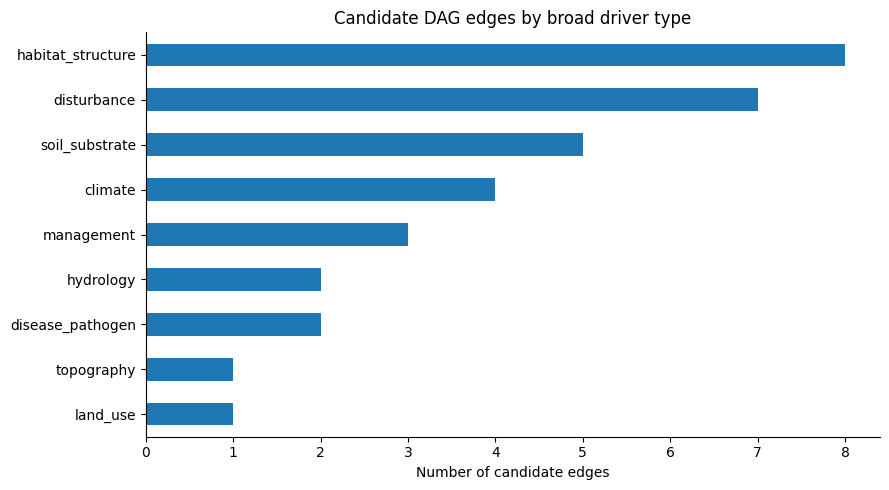

In [15]:
if clustered_edges_df.empty:
    print("No clustered edges to visualise.")
else:
    source_counts = clustered_edges_df["source_type"].value_counts().sort_values()

    ax = source_counts.plot(kind="barh")
    ax.set_title("Candidate DAG edges by broad driver type")
    ax.set_xlabel("Number of candidate edges")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

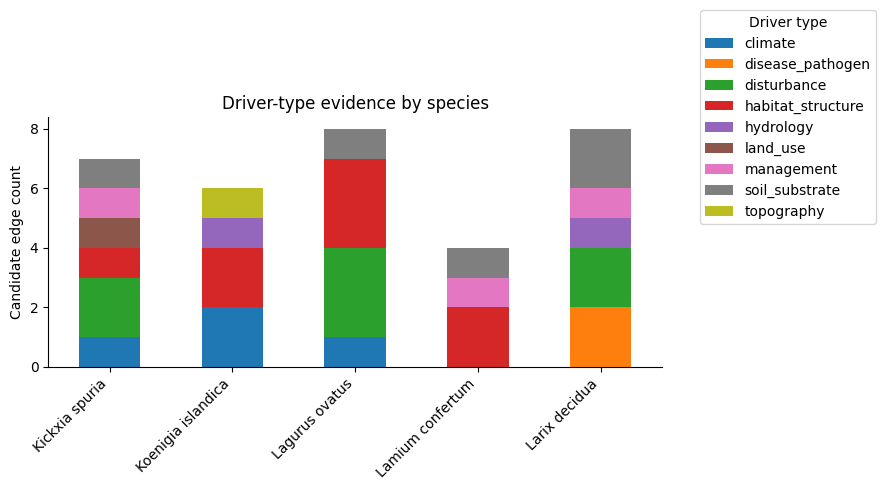

In [16]:
if clustered_edges_df.empty:
    print("No clustered edges to visualise.")
else:
    species_driver_counts = (
        clustered_edges_df.groupby(["canonical", "source_type"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    ax = species_driver_counts.plot(kind="bar", stacked=True)
    ax.set_title("Driver-type evidence by species")
    ax.set_xlabel("")
    ax.set_ylabel("Candidate edge count")
    plt.xticks(rotation=45, ha="right")
    ax.legend(title="Driver type", loc="center left", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

## Aggregate sentence-level evidence into graph edges

The model works at sentence level, but a graph edge should usually aggregate repeated evidence for the same species, source and target. This section combines compatible candidate rows, keeps examples of the raw phrases and quotes, and records the number of supporting sentences.

Aggregation is deliberately conservative. It should make review easier without hiding where the evidence came from.


In [17]:
def join_unique(values: Iterable[Any], sep: str = " | ") -> str:
    out = []
    seen = set()
    for value in values:
        if value is None or (isinstance(value, float) and math.isnan(value)):
            continue
        text = str(value).strip()
        if text and text not in seen:
            seen.add(text)
            out.append(text)
    return sep.join(out)


if clustered_edges_df.empty:
    agg_edges_df = pd.DataFrame()
else:
    agg_edges_df = (
        clustered_edges_df
        .groupby(
            [
                "species_id",
                "canonical",
                "semantic_cluster_label",
                "target_canonical",
                "effect",
            ],
            dropna=False,
        )
        .agg(
            source_types=("source_type", lambda x: join_unique(x, "; ")),
            source_raw_examples=("source_raw", lambda x: join_unique(x, "; ")),
            source_canonical_examples=("source_canonical", lambda x: join_unique(x, "; ")),
            semantic_cluster_ids=("semantic_cluster_id", lambda x: join_unique(x, "; ")),
            n_evidence_sentences=("sentence_id", "nunique"),
            sentence_ids=("sentence_id", lambda x: join_unique([int(v) for v in x], "; ")),
            evidence_quotes=("evidence_quote", lambda x: join_unique(x, " || ")),
            mean_confidence=("confidence", "mean"),
            max_confidence=("confidence", "max"),
            extraction_methods=("extraction_method", lambda x: join_unique(x, "; ")),
        )
        .reset_index()
        .rename(columns={"semantic_cluster_label": "source_canonical"})
    )

    agg_edges_df["edge_origin"] = "text_extracted"
    agg_edges_df["assumption"] = ""
    agg_edges_df["mean_confidence"] = agg_edges_df["mean_confidence"].round(3)
    agg_edges_df["max_confidence"] = agg_edges_df["max_confidence"].round(3)

agg_edges_df.to_csv(OUTPUT_DIR / "all_dag_edges.csv", index=False)

print("Aggregated DAG edges:", len(agg_edges_df))
display(agg_edges_df.head(20))

Aggregated DAG edges: 29


,species_id,canonical,source_canonical,target_canonical,effect,source_types,source_raw_examples,source_canonical_examples,semantic_cluster_ids,n_evidence_sentences,sentence_ids,evidence_quotes,mean_confidence,max_confidence,extraction_methods,edge_origin,assumption
0,demo_001,Kickxia spuria,arable_margins,abundance,negative,disturbance,loss of open cultivated margins,arable_margins,disturbance_001,1,4,but loss of open cultivated margins remains a ...,1.0,1.0,llm_transformers,text_extracted,
1,demo_001,Kickxia spuria,calcareous_soil,abundance,positive,soil_substrate,light calcareous soils,calcareous_soil,soil_substrate_002,1,0,most often on light calcareous soils.,1.0,1.0,llm_transformers,text_extracted,
2,demo_001,Kickxia spuria,crop,habitat suitability,positive,land_use,crop,crop,land_use_001,1,1,It can persist where the crop is open and wher...,1.0,1.0,llm_transformers,text_extracted,
3,demo_001,Kickxia spuria,cultivation,habitat suitability,positive,disturbance,cultivation,cultivation,disturbance_002,1,1,It can persist where the crop is open and wher...,1.0,1.0,llm_transformers,text_extracted,
4,demo_001,Kickxia spuria,dense_vegetation,habitat suitability,negative,habitat_structure,dense competitive vegetation,dense_vegetation,habitat_structure_004,1,2,Dense competitive vegetation and intensive her...,1.0,1.0,llm_transformers,text_extracted,
5,demo_001,Kickxia spuria,herbicide_use,habitat suitability,negative,management,intensive herbicide use,herbicide_use,management_002,1,2,Dense competitive vegetation and intensive her...,1.0,1.0,llm_transformers,text_extracted,
6,demo_001,Kickxia spuria,southern_temperate,abundance,positive,climate,southern-temperate,southern_temperate,climate_002,1,5,A southern-temperate archaeophyte in Britain a...,1.0,1.0,llm_transformers,text_extracted,
7,demo_002,Koenigia islandica,cool_upland_situations,habitat suitability,positive,habitat_structure,cool upland situations,cool_upland_situations,habitat_structure_003,1,0,in cool upland situations.,1.0,1.0,llm_transformers,text_extracted,
8,demo_002,Koenigia islandica,flourishing_conditions,habitat suitability,positive,topography,flourishing conditions,flourishing_conditions,topography_001,1,3,Small colonies may fluctuate between years.,0.9,0.9,llm_transformers,text_extracted,
9,demo_002,Koenigia islandica,reliable_moisture,habitat suitability,positive,hydrology,reliable moisture,reliable_moisture,hydrology_001,1,1,"It depends on short, open vegetation and relia...",1.0,1.0,llm_transformers,text_extracted,


## Add transparent bridge edges

Some extracted relationships point to intermediate concepts such as `habitat suitability` or `population performance` rather than directly to `abundance`. This section adds simple bridge edges from those intermediate nodes to abundance.

These bridge edges are marked as assumptions. They make the graph easier to inspect, but they should still be checked during expert review.


In [18]:
def add_bridge_edges(edges: pd.DataFrame) -> pd.DataFrame:
    if edges.empty:
        return edges

    bridge_rows = []
    for (species_id, canonical, target), group in edges.groupby(["species_id", "canonical", "target_canonical"]):
        if target in {"habitat suitability", "population performance"}:
            bridge_rows.append(
                {
                    "species_id": species_id,
                    "canonical": canonical,
                    "source_canonical": target,
                    "target_canonical": "abundance",
                    "effect": "positive",
                    "source_types": "model_assumption",
                    "source_raw_examples": "",
                    "source_canonical_examples": target,
                    "semantic_cluster_ids": "",
                    "n_evidence_sentences": 0,
                    "sentence_ids": "",
                    "evidence_quotes": "",
                    "mean_confidence": np.nan,
                    "max_confidence": np.nan,
                    "extraction_methods": "",
                    "edge_origin": "model_bridge",
                    "assumption": f"Assumes that higher {target} tends to support higher abundance.",
                }
            )

    if not bridge_rows:
        return edges

    return pd.concat([edges, pd.DataFrame(bridge_rows)], ignore_index=True)


model_augmented_edges_df = add_bridge_edges(agg_edges_df)
model_augmented_edges_df.to_csv(OUTPUT_DIR / "all_dag_edges_with_bridge_edges.csv", index=False)

print("DAG edges after optional bridge edges:", len(model_augmented_edges_df))
display(model_augmented_edges_df.tail(10))

DAG edges after optional bridge edges: 35


,species_id,canonical,source_canonical,target_canonical,effect,source_types,source_raw_examples,source_canonical_examples,semantic_cluster_ids,n_evidence_sentences,sentence_ids,evidence_quotes,mean_confidence,max_confidence,extraction_methods,edge_origin,assumption
25,demo_005,Larix decidua,larch_pathogens,abundance,negative,disease_pathogen,larch pathogens,larch_pathogens,disease_pathogen_001,2,4; 5,Disease pressure from larch pathogens and fell...,0.85,1.0,llm_transformers,text_extracted,
26,demo_005,Larix decidua,rocky_ground,habitat suitability,positive,soil_substrate,open rocky ground,rocky_ground,soil_substrate_004,1,1,regenerates from seed on disturbed mineral soi...,1.00,1.0,llm_transformers,text_extracted,
27,demo_005,Larix decidua,sites_waterlogged_soils,habitat suitability,negative,hydrology,dry sites and waterlogged soils,sites_waterlogged_soils,hydrology_002,1,2,Very dry sites and waterlogged soils are less ...,1.00,1.0,llm_transformers,text_extracted,
28,demo_005,Larix decidua,soil_disturbance,abundance,positive,disturbance,soil disturbance,soil_disturbance,disturbance_006,1,3,Natural regeneration can follow soil disturban...,1.00,1.0,llm_transformers,text_extracted,
29,demo_001,Kickxia spuria,habitat suitability,abundance,positive,model_assumption,,habitat suitability,,0,,,NaN,NaN,,model_bridge,Assumes that higher habitat suitability tends ...
30,demo_002,Koenigia islandica,habitat suitability,abundance,positive,model_assumption,,habitat suitability,,0,,,NaN,NaN,,model_bridge,Assumes that higher habitat suitability tends ...
31,demo_003,Lagurus ovatus,habitat suitability,abundance,positive,model_assumption,,habitat suitability,,0,,,NaN,NaN,,model_bridge,Assumes that higher habitat suitability tends ...
32,demo_003,Lagurus ovatus,population performance,abundance,positive,model_assumption,,population performance,,0,,,NaN,NaN,,model_bridge,Assumes that higher population performance ten...
33,demo_004,Lamium confertum,habitat suitability,abundance,positive,model_assumption,,habitat suitability,,0,,,NaN,NaN,,model_bridge,Assumes that higher habitat suitability tends ...
34,demo_005,Larix decidua,habitat suitability,abundance,positive,model_assumption,,habitat suitability,,0,,,NaN,NaN,,model_bridge,Assumes that higher habitat suitability tends ...


## Build graph objects and check for cycles

This section turns the aggregated edge table into one graph per species and checks whether the graph is acyclic. The graph representation is mainly a way to organise review.

Acyclicity is useful because the intended downstream use is a candidate DAG. However, an automatically produced cycle is not necessarily an ecological failure. It may show that the schema needs refinement or that a bidirectional process has been flattened into directed edges.


In [19]:
def build_species_graph(edges: pd.DataFrame, species_id: str) -> nx.DiGraph:
    graph = nx.DiGraph()
    subset = edges[edges["species_id"] == species_id]

    for _, row in subset.iterrows():
        source = row["source_canonical"]
        target = row["target_canonical"]
        if not source or not target or source == target:
            continue

        graph.add_node(source, node_type="driver" if source not in {"habitat suitability", "population performance",
                                                                    "abundance"} else "intermediate")
        graph.add_node(target, node_type="outcome" if target == "abundance" else "intermediate")

        graph.add_edge(
            source,
            target,
            effect=row["effect"],
            edge_origin=row["edge_origin"],
            weight=row["mean_confidence"] if pd.notna(row["mean_confidence"]) else 0.5,
            n_evidence_sentences=int(row.get("n_evidence_sentences", 0)),
            evidence_quotes=row.get("evidence_quotes", ""),
        )

    return graph


cycle_rows = []
node_rows = []

for species_id, group in model_augmented_edges_df.groupby("species_id"):
    canonical = group["canonical"].iloc[0]
    graph = build_species_graph(model_augmented_edges_df, species_id)

    is_dag = nx.is_directed_acyclic_graph(graph)
    cycles = []
    if not is_dag:
        try:
            cycles = list(nx.simple_cycles(graph))[:5]
        except Exception:
            cycles = []

    cycle_rows.append(
        {
            "species_id": species_id,
            "canonical": canonical,
            "n_nodes": graph.number_of_nodes(),
            "n_edges": graph.number_of_edges(),
            "is_dag": is_dag,
            "example_cycles": json.dumps(cycles),
        }
    )

    for node, attrs in graph.nodes(data=True):
        node_rows.append(
            {
                "species_id": species_id,
                "canonical": canonical,
                "node": node,
                "node_type": attrs.get("node_type", ""),
            }
        )

dag_diagnostics_df = pd.DataFrame(cycle_rows)
dag_nodes_df = pd.DataFrame(node_rows)

dag_diagnostics_df.to_csv(OUTPUT_DIR / "dag_diagnostics.csv", index=False)
dag_nodes_df.to_csv(OUTPUT_DIR / "all_dag_nodes.csv", index=False)

display(dag_diagnostics_df)

,species_id,canonical,n_nodes,n_edges,is_dag,example_cycles
0,demo_001,Kickxia spuria,9,8,True,[]
1,demo_002,Koenigia islandica,7,6,True,[]
2,demo_003,Lagurus ovatus,8,8,True,[]
3,demo_004,Lamium confertum,5,5,True,[]
4,demo_005,Larix decidua,8,8,True,[]


## Visualise one species graph

The plot below is deliberately closer to a hand-drawn causal diagram than to a generic network plot. `abundance` is placed as the focal outcome and short driver labels are arranged around it. Positive and negative relationships are shown differently because the sign is one of the most useful review fields.

The full evidence phrases remain in the review table. The shortened node labels are only used to make the figure readable.


Saved: outputs_plant_atlas_llm_to_dag/visualisations/Lagurus_ovatus_candidate_dag.png


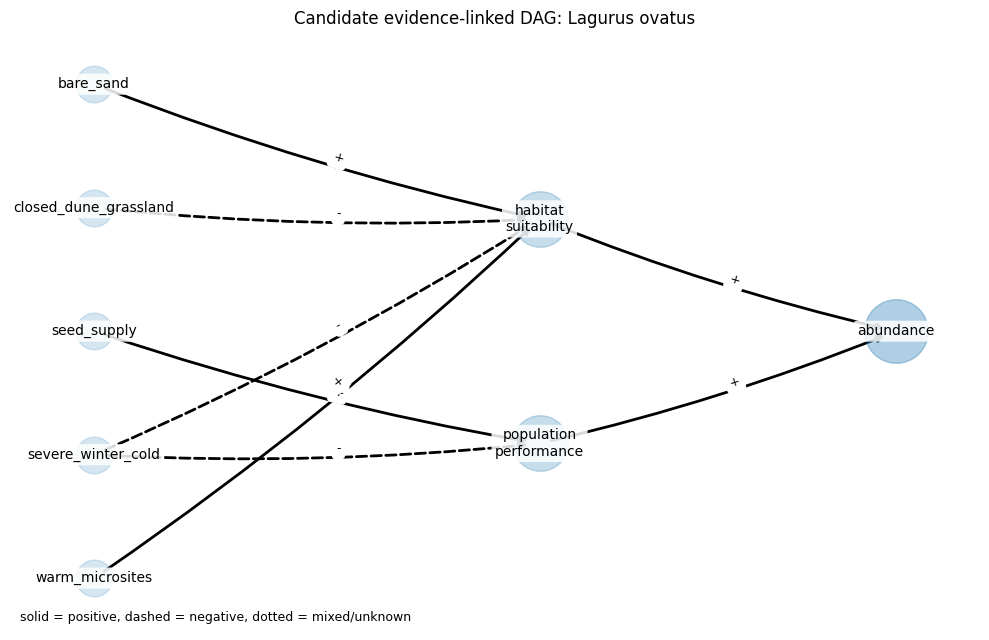

In [20]:
VIS_DIR = OUTPUT_DIR / "visualisations"
VIS_DIR.mkdir(parents=True, exist_ok=True)


def display_label(node: str) -> str:
    """Short label used only for graph plotting."""
    if node == "abundance":
        return "abundance"
    if node == "habitat suitability":
        return "habitat\nsuitability"
    if node == "population performance":
        return "population\nperformance"

    text = str(node).replace(" ", "_")
    parts = [p for p in text.split("_") if p]
    if len(parts) <= 3:
        return "_".join(parts)

    # Keep labels compact. The evidence table keeps the full phrase.
    return "_".join(parts[:2]) + "\n" + "_".join(parts[2:4])


def outcome_focused_layout(graph: nx.DiGraph) -> dict[str, tuple[float, float]]:
    """Place abundance as the focal outcome and arrange drivers around it."""
    pos: dict[str, tuple[float, float]] = {}

    outcomes = [n for n in ["abundance"] if n in graph]
    intermediates = [n for n in ["habitat suitability", "population performance"] if n in graph]
    drivers = [n for n in graph.nodes if n not in set(outcomes + intermediates)]

    if "abundance" in graph:
        pos["abundance"] = (0.0, 0.0)

    if intermediates:
        y_values = np.linspace(1.0, -1.0, len(intermediates))
        for node, y in zip(intermediates, y_values):
            pos[node] = (-1.6, float(y))

    direct_drivers = [n for n in drivers if graph.has_edge(n, "abundance")]
    indirect_drivers = [n for n in drivers if n not in direct_drivers]

    def place_nodes(nodes: list[str], x: float, y_top: float, y_bottom: float) -> None:
        if not nodes:
            return
        y_values = np.linspace(y_top, y_bottom, len(nodes))
        for node, y in zip(nodes, y_values):
            pos[node] = (x, float(y))

    # Direct abundance drivers are closest to the focal outcome. Indirect drivers
    # sit further left, feeding through habitat or population-performance nodes.
    place_nodes(sorted(direct_drivers), -1.9, 1.9, -1.9)
    place_nodes(sorted(indirect_drivers), -3.6, 2.2, -2.2)

    # Fall back for any unexpected isolated node.
    missing = [n for n in graph.nodes if n not in pos]
    if missing:
        fallback = nx.spring_layout(graph.subgraph(missing), seed=RANDOM_SEED)
        for node, xy in fallback.items():
            pos[node] = (float(xy[0]) - 3.0, float(xy[1]))

    return pos


def draw_effect_edges(graph: nx.DiGraph, pos: dict[str, tuple[float, float]]) -> None:
    positive_edges = [(u, v) for u, v, a in graph.edges(data=True) if a.get("effect") == "positive"]
    negative_edges = [(u, v) for u, v, a in graph.edges(data=True) if a.get("effect") == "negative"]
    other_edges = [(u, v) for u, v, a in graph.edges(data=True) if a.get("effect") not in {"positive", "negative"}]

    nx.draw_networkx_edges(
        graph, pos, edgelist=positive_edges, arrows=True, arrowstyle="-|>",
        width=2.0, connectionstyle="arc3,rad=0.04"
    )
    nx.draw_networkx_edges(
        graph, pos, edgelist=negative_edges, arrows=True, arrowstyle="-|>",
        width=2.0, style="dashed", connectionstyle="arc3,rad=0.04"
    )
    nx.draw_networkx_edges(
        graph, pos, edgelist=other_edges, arrows=True, arrowstyle="-|>",
        width=1.5, style="dotted", connectionstyle="arc3,rad=0.04"
    )

    # Use + and - instead of full words; it keeps the graph closer to a causal
    # diagram while retaining the direction of effect.
    edge_labels = {}
    for u, v, attrs in graph.edges(data=True):
        effect = attrs.get("effect", "")
        edge_labels[(u, v)] = {"positive": "+", "negative": "-", "mixed": "+/-"}.get(effect, "?")
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=9, label_pos=0.55)


def plot_species_graph(species_id: str, save: bool = True) -> None:
    graph = build_species_graph(model_augmented_edges_df, species_id)
    if graph.number_of_edges() == 0:
        print("No graph edges for", species_id)
        return

    canonical = model_augmented_edges_df.loc[model_augmented_edges_df["species_id"] == species_id, "canonical"].iloc[0]
    pos = outcome_focused_layout(graph)

    plt.figure(figsize=(10, 6.5))

    outcome_nodes = [n for n, a in graph.nodes(data=True) if a.get("node_type") == "outcome"]
    intermediate_nodes = [n for n, a in graph.nodes(data=True) if a.get("node_type") == "intermediate"]
    driver_nodes = [n for n, a in graph.nodes(data=True) if a.get("node_type") == "driver"]

    nx.draw_networkx_nodes(graph, pos, nodelist=driver_nodes, node_size=700, alpha=0.18)
    nx.draw_networkx_nodes(graph, pos, nodelist=intermediate_nodes, node_size=1600, alpha=0.25)
    nx.draw_networkx_nodes(graph, pos, nodelist=outcome_nodes, node_size=2100, alpha=0.35)

    draw_effect_edges(graph, pos)

    labels = {node: display_label(node) for node in graph.nodes}
    nx.draw_networkx_labels(
        graph,
        pos,
        labels=labels,
        font_size=10,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.85},
    )

    plt.title(f"Candidate evidence-linked DAG: {canonical}")
    plt.text(
        0.01, 0.01,
        "solid = positive, dashed = negative, dotted = mixed/unknown",
        transform=plt.gca().transAxes,
        fontsize=9,
        va="bottom",
    )
    plt.axis("off")
    plt.tight_layout()

    if save:
        safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", canonical)
        path = VIS_DIR / f"{safe_name}_candidate_dag.png"
        plt.savefig(path, dpi=180, bbox_inches="tight")
        print("Saved:", path)

    plt.show()


species_with_edges = dag_diagnostics_df.loc[dag_diagnostics_df["n_edges"] > 0, "species_id"].tolist()
if species_with_edges:
    plot_species_graph(species_with_edges[2])
else:
    print("No species graphs to plot.")


In [21]:
# Save all species DAG plots for review using the same outcome-focused layout.
saved = []
for species_id in species_with_edges:
    graph = build_species_graph(model_augmented_edges_df, species_id)
    if graph.number_of_edges() == 0:
        continue

    canonical = model_augmented_edges_df.loc[model_augmented_edges_df["species_id"] == species_id, "canonical"].iloc[0]
    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", canonical)
    path = VIS_DIR / f"{safe_name}_candidate_dag.png"

    pos = outcome_focused_layout(graph)
    plt.figure(figsize=(10, 6.5))

    outcome_nodes = [n for n, a in graph.nodes(data=True) if a.get("node_type") == "outcome"]
    intermediate_nodes = [n for n, a in graph.nodes(data=True) if a.get("node_type") == "intermediate"]
    driver_nodes = [n for n, a in graph.nodes(data=True) if a.get("node_type") == "driver"]

    nx.draw_networkx_nodes(graph, pos, nodelist=driver_nodes, node_size=700, alpha=0.18)
    nx.draw_networkx_nodes(graph, pos, nodelist=intermediate_nodes, node_size=1600, alpha=0.25)
    nx.draw_networkx_nodes(graph, pos, nodelist=outcome_nodes, node_size=2100, alpha=0.35)
    draw_effect_edges(graph, pos)
    nx.draw_networkx_labels(
        graph,
        pos,
        labels={node: display_label(node) for node in graph.nodes},
        font_size=10,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.85},
    )
    plt.title(f"Candidate evidence-linked DAG: {canonical}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.close()
    saved.append(path)

print(f"Saved {len(saved)} DAG plot(s) to {VIS_DIR}")


Saved 5 DAG plot(s) to outputs_plant_atlas_llm_to_dag/visualisations


## Expert-review table

This table is the main hand-off from the automated workflow to ecological review. It keeps the species, source node, target node, effect direction, evidence quotes, confidence summaries and assumption flags in one place.

The LLM output is not treated as final. The table is designed so that a reviewer can accept, edit, merge or reject candidate edges while seeing the source evidence.


In [22]:
review_cols = [
    "species_id",
    "canonical",
    "edge_origin",
    "source_canonical",
    "target_canonical",
    "effect",
    "source_types",
    "mean_confidence",
    "max_confidence",
    "n_evidence_sentences",
    "source_raw_examples",
    "source_canonical_examples",
    "semantic_cluster_ids",
    "sentence_ids",
    "evidence_quotes",
    "assumption",
    "expert_decision",
    "expert_source_edit",
    "expert_target_edit",
    "expert_effect_edit",
    "expert_notes",
]

expert_review_df = model_augmented_edges_df.copy()
for col in ["expert_decision", "expert_source_edit", "expert_target_edit", "expert_effect_edit", "expert_notes"]:
    expert_review_df[col] = ""

expert_review_df = expert_review_df[[c for c in review_cols if c in expert_review_df.columns]]
expert_review_df.to_csv(OUTPUT_DIR / "expert_review_edges.csv", index=False)

display(expert_review_df.head(20))
print("Expert-review CSV:", OUTPUT_DIR / "expert_review_edges.csv")

,species_id,canonical,edge_origin,source_canonical,target_canonical,effect,source_types,mean_confidence,max_confidence,n_evidence_sentences,...,source_canonical_examples,semantic_cluster_ids,sentence_ids,evidence_quotes,assumption,expert_decision,expert_source_edit,expert_target_edit,expert_effect_edit,expert_notes
0,demo_001,Kickxia spuria,text_extracted,arable_margins,abundance,negative,disturbance,1.0,1.0,1,...,arable_margins,disturbance_001,4,but loss of open cultivated margins remains a ...,,,,,,
1,demo_001,Kickxia spuria,text_extracted,calcareous_soil,abundance,positive,soil_substrate,1.0,1.0,1,...,calcareous_soil,soil_substrate_002,0,most often on light calcareous soils.,,,,,,
2,demo_001,Kickxia spuria,text_extracted,crop,habitat suitability,positive,land_use,1.0,1.0,1,...,crop,land_use_001,1,It can persist where the crop is open and wher...,,,,,,
3,demo_001,Kickxia spuria,text_extracted,cultivation,habitat suitability,positive,disturbance,1.0,1.0,1,...,cultivation,disturbance_002,1,It can persist where the crop is open and wher...,,,,,,
4,demo_001,Kickxia spuria,text_extracted,dense_vegetation,habitat suitability,negative,habitat_structure,1.0,1.0,1,...,dense_vegetation,habitat_structure_004,2,Dense competitive vegetation and intensive her...,,,,,,
5,demo_001,Kickxia spuria,text_extracted,herbicide_use,habitat suitability,negative,management,1.0,1.0,1,...,herbicide_use,management_002,2,Dense competitive vegetation and intensive her...,,,,,,
6,demo_001,Kickxia spuria,text_extracted,southern_temperate,abundance,positive,climate,1.0,1.0,1,...,southern_temperate,climate_002,5,A southern-temperate archaeophyte in Britain a...,,,,,,
7,demo_002,Koenigia islandica,text_extracted,cool_upland_situations,habitat suitability,positive,habitat_structure,1.0,1.0,1,...,cool_upland_situations,habitat_structure_003,0,in cool upland situations.,,,,,,
8,demo_002,Koenigia islandica,text_extracted,flourishing_conditions,habitat suitability,positive,topography,0.9,0.9,1,...,flourishing_conditions,topography_001,3,Small colonies may fluctuate between years.,,,,,,
9,demo_002,Koenigia islandica,text_extracted,reliable_moisture,habitat suitability,positive,hydrology,1.0,1.0,1,...,reliable_moisture,hydrology_001,1,"It depends on short, open vegetation and relia...",,,,,,


Expert-review CSV: outputs_plant_atlas_llm_to_dag/expert_review_edges.csv


## Run summary and metadata

The summary table gives one row per species, and the metadata JSON records the key settings used in the run. This is important for LLM-assisted workflows because changes in the model, prompt, token limit or batch settings can change the extracted records.


In [23]:
summary_rows = []

for _, species in species_text.iterrows():
    species_id = species["species_id"]
    summary_rows.append(
        {
            "species_id": species_id,
            "canonical": species["canonical"],
            "n_sentences": int((sentences_df["species_id"] == species_id).sum()),
            "n_raw_candidate_edges": int((raw_edges_df["species_id"] == species_id).sum()) if len(raw_edges_df) else 0,
            "n_validated_dag_edges": int((clustered_edges_df["species_id"] == species_id).sum()) if len(
                clustered_edges_df) else 0,
            "n_aggregated_text_edges": int((agg_edges_df["species_id"] == species_id).sum()) if len(
                agg_edges_df) else 0,
            "n_augmented_dag_edges": int((model_augmented_edges_df["species_id"] == species_id).sum()) if len(
                model_augmented_edges_df) else 0,
        }
    )

summary_df = pd.DataFrame(summary_rows).merge(
    dag_diagnostics_df[["species_id", "n_nodes", "n_edges", "is_dag"]],
    on="species_id",
    how="left",
)

summary_df.to_csv(OUTPUT_DIR / "run_summary.csv", index=False)

_NOTEBOOK_END_TIME = dt.datetime.now()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
elapsed_minutes = round(_NOTEBOOK_ELAPSED.total_seconds() / 60, 2)

run_metadata = {
    "created_at": _NOTEBOOK_END_TIME.isoformat(timespec="seconds"),
    "elapsed_minutes": elapsed_minutes,
    "run_config_hash": RUN_CONFIG_HASH,
    "run_config": RUN_CONFIG,
    "python_version": os.sys.version,
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "networkx_version": nx.__version__,
    "output_dir": str(OUTPUT_DIR),
    "development_hardware": {
        "gpu": "NVIDIA GeForce RTX 3060 Laptop GPU",
        "gpu_memory_mib": 6144,
        "nvidia_smi": "580.126.09",
        "driver_version": "580.126.09",
        "cuda_version_reported_by_nvidia_smi": "13.0",
    },
}

with open(OUTPUT_DIR / "run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)

display(summary_df)
print(f"Notebook elapsed time: {elapsed_minutes} minutes")
print("Run metadata:", OUTPUT_DIR / "run_metadata.json")


,species_id,canonical,n_sentences,n_raw_candidate_edges,n_validated_dag_edges,n_aggregated_text_edges,n_augmented_dag_edges,n_nodes,n_edges,is_dag
0,demo_001,Kickxia spuria,6,8,7,7,8,9,8,True
1,demo_002,Koenigia islandica,6,6,6,5,6,7,6,True
2,demo_003,Lagurus ovatus,6,9,8,6,8,8,8,True
3,demo_004,Lamium confertum,6,6,4,4,5,5,5,True
4,demo_005,Larix decidua,6,8,8,7,8,8,8,True


Notebook elapsed time: 7.87 minutes
Run metadata: outputs_plant_atlas_llm_to_dag/run_metadata.json


## Output files

The notebook writes the following files:

- `species_text_table.csv`: species-level source text used in the run;
- `all_sentences.csv`: sentence-level evidence units with neighbouring context;
- `baseline_deterministic_candidate_edges.csv`: simple rule-based extraction used only as a sanity check;
- `all_raw_candidate_edges.csv`: parsed LLM candidate edges;
- `llm_extraction_audit.csv`: sentence-level LLM parsing audit;
- `all_candidate_edges_validated.csv`: candidate rows with validation flags;
- `all_candidate_edges_clustered.csv`: candidate rows with simple phrase-cluster identifiers;
- `driver_semantic_clusters.csv`: one row per simple driver phrase cluster;
- `all_dag_edges.csv`: aggregated sentence-level evidence as graph edges;
- `all_dag_edges_with_bridge_edges.csv`: aggregated edges plus transparent bridge edges to abundance;
- `dag_diagnostics.csv`: node and edge counts and cycle checks;
- `all_dag_nodes.csv`: graph nodes and node types;
- `expert_review_edges.csv`: the main review hand-off table;
- `run_summary.csv`: one-row-per-species summary;
- `run_metadata.json`: model path, generation settings, run hash and development hardware metadata;
- `visualisations/*.png`: simple graph plots for species with extracted edges.

The review table is the main product. The graph plots and diagnostics help spot obvious problems before detailed ecological review.


## Conclusions

This notebook shows a practical route from species-account prose to evidence-linked candidate graph edges using a small local LLM. The design keeps the model task narrow: one sentence, one prompt, one JSON schema and explicit validation afterwards.

For the synthetic Plant Atlas-style example, the output should be read as a candidate review table rather than accepted ecological knowledge. The model proposes rows; the analyst decides whether the evidence is useful, whether the direction is plausible and whether the proposed edge belongs in a causal diagram.

The workflow is intentionally modular. If a different local model is used, only the model-loading and prompt-tuning parts should need attention. If a different text source is used, the same sentence-grounded extraction and validation pattern may still be useful.


## References

Boyd, R. J., Botham, M., Dennis, E., Fox, R., Harrower, C., Middlebrook, I., Roy, D. B., & Pescott, O. L. (2025). *Using causal diagrams and superpopulation models to correct geographic biases in biodiversity monitoring data*. Methods in Ecology and Evolution. https://doi.org/10.1111/2041-210X.14492

Botanical Society of Britain and Ireland. (2023). *Plant Atlas 2020*. https://plantatlas2020.org/

Hugging Face. *Transformers documentation: bitsandbytes quantization*. https://huggingface.co/docs/transformers/quantization/bitsandbytes

Hugging Face. *Transformers installation/offline mode documentation*. https://huggingface.co/docs/transformers/installation#offline-mode

Torrance, A. W. (2024). *The environmental impacts of large language models*. Scientific Reports, 14, 25020. https://doi.org/10.1038/s41598-024-76682-6
